In [1]:
import pandas as pd
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold

from scipy import stats
from scipy.stats import ttest_ind, pearsonr

RANDOM_STATE = 42

import warnings
warnings.filterwarnings("ignore")

## Load/Process Data

In [2]:
# =====================================================
# Folder Paths
# =====================================================

aqi_folder = r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Dataset\AQI"
ev_folder = r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Dataset\EV"
green_cover_file = r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Dataset\GreenCover\greenCover.xlsx"
population_file = r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Dataset\Population\populationDensity.xlsx"
smart_city_file = r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Dataset\SmartCity\smartCity.xlsx"

# =====================================================
# LOAD AQI DATA
# =====================================================

aqi_list = []

for city in os.listdir(aqi_folder):

    city_path = os.path.join(aqi_folder, city)

    if os.path.isdir(city_path):

        for file in os.listdir(city_path):

            if file.lower().endswith(".csv"):

                filepath = os.path.join(city_path, file)

                try:
                    df = pd.read_csv(filepath, encoding="utf-8")
                except:
                    df = pd.read_csv(filepath, encoding="latin1")

                df["City"] = city

                year = int(file.replace(".csv", "").split("_")[-1])

                df["Year"] = year

                aqi_list.append(df)

aqi_df = pd.concat(aqi_list, ignore_index=True)

print("AQI Loaded:", aqi_df.shape)

# =====================================================
# CONVERT AQI COLUMNS TO NUMERIC
# =====================================================

exclude = ["Timestamp", "City", "Year"]

for col in aqi_df.columns:

    if col not in exclude:

        aqi_df[col] = pd.to_numeric(
            aqi_df[col],
            errors="coerce"
        )

# =====================================================
# CREATE YEARLY AVERAGES
# =====================================================

annual_aqi = (
    aqi_df
    .groupby(["City", "Year"], as_index=False)
    .mean(numeric_only=True)
)

print("Annual AQI Shape:", annual_aqi.shape)

# =====================================================
# LOAD EV DATA
# =====================================================

ev_list = []

for file in os.listdir(ev_folder):

    if file.lower().endswith(".xlsx"):

        city = (
            file.replace("ev_", "")
            .replace(".xlsx", "")
            .title()
        )

        filepath = os.path.join(ev_folder, file)

        df = pd.read_excel(filepath, header=None)

        temp = pd.DataFrame({

            "Year": df.iloc[0, 1:].astype(int),

            "EV": pd.to_numeric(
                df.iloc[1, 1:],
                errors="coerce"
            )

        })

        temp["City"] = city

        ev_list.append(temp)

ev_df = pd.concat(ev_list, ignore_index=True)

print("EV Loaded:", ev_df.shape)

# =====================================================
# LOAD GREEN COVER DATA
# =====================================================

green_df = pd.read_excel(green_cover_file)

green_df.columns = green_df.columns.str.strip()

green_df.rename(
    columns={
        green_df.columns[1]: "GreenCover"
    },
    inplace=True
)

green_df["GreenCover"] = (
    green_df["GreenCover"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

green_df["GreenCover"] = pd.to_numeric(
    green_df["GreenCover"],
    errors="coerce"
)

green_df["City"] = green_df["City"].str.strip()

print("Green Cover Loaded:", green_df.shape)

# =====================================================
# LOAD POPULATION DENSITY DATA
# =====================================================

population_df = pd.read_excel(population_file)

population_df.columns = population_df.columns.str.strip()

population_df.rename(
    columns={
        population_df.columns[1]: "PopulationDensity"
    },
    inplace=True
)

population_df["PopulationDensity"] = (
    population_df["PopulationDensity"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

population_df["PopulationDensity"] = pd.to_numeric(
    population_df["PopulationDensity"],
    errors="coerce"
)

population_df["City"] = population_df["City"].str.strip()

print("Population Loaded:", population_df.shape)

# =====================================================
# LOAD SMART CITY DATA
# =====================================================

smart_df = pd.read_excel(smart_city_file)

smart_df.columns = smart_df.columns.str.strip()

smart_df.rename(
    columns={
        "smartCity_status": "SmartCity"
    },
    inplace=True
)

smart_df["SmartCity"] = pd.to_numeric(
    smart_df["SmartCity"],
    errors="coerce"
)

smart_df["City"] = smart_df["City"].str.strip()

print("Smart City Loaded:", smart_df.shape)

# =====================================================
# STANDARDIZE CITY NAMES
# =====================================================

annual_aqi["City"] = annual_aqi["City"].str.strip().str.title()
ev_df["City"] = ev_df["City"].str.strip().str.title()
green_df["City"] = green_df["City"].str.strip().str.title()
population_df["City"] = population_df["City"].str.strip().str.title()
smart_df["City"] = smart_df["City"].str.strip().str.title()

# =====================================================
# MERGE DATASETS
# =====================================================

final_df = (
    annual_aqi
    .merge(
        ev_df,
        on=["City", "Year"],
        how="left"
    )
    .merge(
        green_df,
        on="City",
        how="left"
    )
    .merge(
        population_df,
        on="City",
        how="left"
    )
    .merge(
        smart_df,
        on="City",
        how="left"
    )
)

# =======================================
# KEEP ONLY VARIABLES REQUIRED
# =======================================

required_columns = [
    "City",
    "Year",
    "PM2.5 (µg/m³)",
    "SmartCity",
    "EV",
    "GreenCover",
    "PopulationDensity",
    "AT (°C)",
    "RH (%)",
    "WS (m/s)",
    "RF (mm)"
]

missing_columns = [
    col for col in required_columns
    if col not in final_df.columns
]

if missing_columns:
    print("\nMissing Columns:")
    print(missing_columns)

final_df = final_df[
    [col for col in required_columns if col in final_df.columns]
]

# =====================================================
# FINAL DATASET CHECK
# =====================================================

print("\nFinal Dataset Shape:")
print(final_df.shape)

print("\nFinal Columns:")
print(final_df.columns.tolist())

print("\nMissing Values:")
print(final_df.isnull().sum())

print("\nSample Records:")
print(final_df.head())

# =====================================================
# SAVE FINAL DATASET
# =====================================================

output_file = (
    r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Dataset\Final_PM25_SmartCity_EV_GreenCover_Population.csv"
)

final_df.to_csv(
    output_file,
    index=False
)

print("\nDataset saved successfully!")
print(output_file)

AQI Loaded: (68543, 27)
Annual AQI Shape: (191, 26)
EV Loaded: (216, 3)
Green Cover Loaded: (23, 2)
Population Loaded: (23, 2)
Smart City Loaded: (23, 2)

Final Dataset Shape:
(191, 11)

Final Columns:
['City', 'Year', 'PM2.5 (µg/m³)', 'SmartCity', 'EV', 'GreenCover', 'PopulationDensity', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'RF (mm)']

Missing Values:
City                   0
Year                   0
PM2.5 (µg/m³)         54
SmartCity              0
EV                     0
GreenCover             0
PopulationDensity      0
AT (°C)              105
RH (%)                85
WS (m/s)              68
RF (mm)              108
dtype: int64

Sample Records:
        City  Year  PM2.5 (µg/m³)  SmartCity    EV  GreenCover  \
0  Bengaluru  2017      21.429870          1    36      284.28   
1  Bengaluru  2018      27.814315          1   168      284.28   
2  Bengaluru  2019      46.559576          1   451      284.28   
3  Bengaluru  2020      34.763758          1  1022      284.28   
4  Bengaluru  

In [3]:
final_df.head()

,City,Year,PM2.5 (µg/m³),SmartCity,EV,GreenCover,PopulationDensity,AT (°C),RH (%),WS (m/s),RF (mm)
0,Bengaluru,2017,21.429870,1,36,284.28,240.7,27.919345,71.941104,0.826012,NaN
1,Bengaluru,2018,27.814315,1,168,284.28,240.7,25.130621,59.656939,0.784408,NaN
2,Bengaluru,2019,46.559576,1,451,284.28,240.7,25.591761,72.115451,0.820179,NaN
3,Bengaluru,2020,34.763758,1,1022,284.28,240.7,27.187890,60.276724,0.925704,NaN
4,Bengaluru,2021,32.942624,1,2561,284.28,240.7,25.355325,65.767486,2.218931,NaN


In [4]:
final_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Year,191.0,2021.130890,2.597294,2017.000000,2019.000000,2021.000000,2023.000000,2025.000000
PM2.5 (µg/m³),137.0,47.762285,17.428121,16.707048,35.871573,46.948705,58.288581,110.602373
SmartCity,191.0,0.528796,0.500482,0.000000,0.000000,1.000000,1.000000,1.000000
EV,191.0,8769.465969,16032.363527,0.000000,173.000000,1640.000000,9803.000000,97352.000000
GreenCover,191.0,826.140157,782.235116,0.930000,60.070000,564.580000,1490.520000,2713.630000
PopulationDensity,191.0,236.675602,150.654205,52.800000,129.630000,207.130000,288.810000,700.130000
AT (°C),86.0,25.536112,3.143749,11.382941,24.843589,25.702132,27.176819,29.940389
RH (%),106.0,65.869013,10.204877,23.636087,60.056717,67.403318,72.849479,84.092267
WS (m/s),123.0,1.576786,1.824399,0.395546,0.635407,1.091693,1.700953,11.211292
RF (mm),83.0,0.083848,0.256988,0.000000,0.010678,0.022887,0.035893,1.873747


In [5]:
final_df.shape

(191, 11)

In [6]:
final_df.dtypes

City                  object
Year                   int64
PM2.5 (µg/m³)        float64
SmartCity              int64
EV                     int64
GreenCover           float64
PopulationDensity    float64
AT (°C)              float64
RH (%)               float64
WS (m/s)             float64
RF (mm)              float64
dtype: object

In [7]:
final_df.isnull().sum()

City                   0
Year                   0
PM2.5 (µg/m³)         54
SmartCity              0
EV                     0
GreenCover             0
PopulationDensity      0
AT (°C)              105
RH (%)                85
WS (m/s)              68
RF (mm)              108
dtype: int64

In [8]:
final_df.duplicated().sum()

0

## Exploratory Data Analysis

In [9]:
# 1. Define variables precisely
weather_cols = ["PM2.5 (µg/m³)", "AT (°C)", "RH (%)", "WS (m/s)", "RF (mm)"]

# 2. Sort chronologically for timeline interpolation accuracy
final_df = final_df.sort_values(by=["City", "Year"])

# 3. Clean in 3 cascading tiers
for col in weather_cols:
    if col in final_df.columns:
        
        # Tier 1: Interpolate linearly within each city group
        final_df[col] = final_df.groupby("City")[col].transform(
            lambda x: x.interpolate(method="linear", limit_direction="both")
        )
        
        # Tier 2: Fill remaining NaNs using the average of all cities for that specific Year
        final_df[col] = final_df.groupby("Year")[col].transform(
            lambda x: x.fillna(x.mean())
        )
        
        # Tier 3: Absolute fallback (if an entire Year was missing everywhere)
        # Uses the global historical average for that specific sensor metric
        global_mean = final_df[col].mean()
        final_df[col] = final_df[col].fillna(global_mean)

# 4. Re-verify missing values (Every single value should now be 0)
print("\n--- Final Imputation Verification ---")
print(final_df[weather_cols].isnull().sum())


--- Final Imputation Verification ---
PM2.5 (µg/m³)    0
AT (°C)          0
RH (%)           0
WS (m/s)         0
RF (mm)          0
dtype: int64


## Univariate Analysis : Histplot & Boxplot

In [10]:
final_df.rename(columns={"PM2.5 (µg/m³)": "PM2.5"}, inplace=True)
final_df.rename(columns={"AT (°C)": "AT"}, inplace=True)
final_df.rename(columns={"RH (%)": "RH"}, inplace=True)
final_df.rename(columns={"WS (m/s)": "WS"}, inplace=True)
final_df.rename(columns={"RF (mm)": "RF"}, inplace=True)
numeric_columns = [
    "PM2.5",
    "EV",
    "GreenCover",
    "PopulationDensity",
    "AT",
    "RH",
    "WS",
    "RF"
]

for column in numeric_columns:
    negative = (final_df[column] < 0).sum()
    print(f"{column}: {negative}")

PM2.5: 0
EV: 0
GreenCover: 0
PopulationDensity: 0
AT: 0
RH: 0
WS: 0
RF: 0


Year
Skew : -0.07


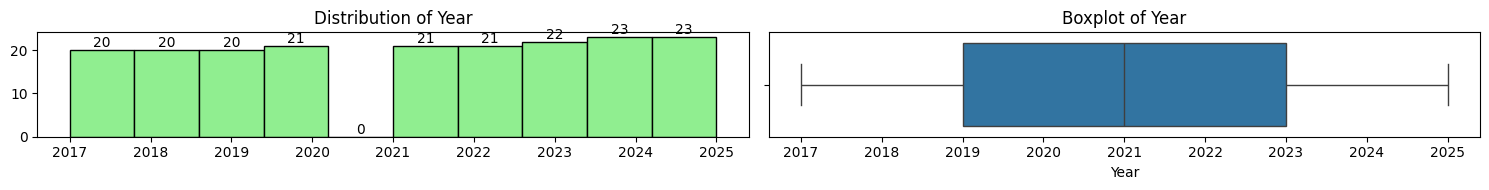

PM2.5
Skew : 1.01


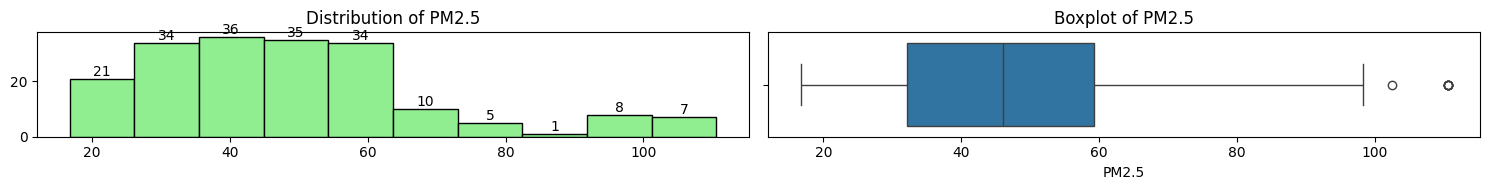

SmartCity
Skew : -0.12


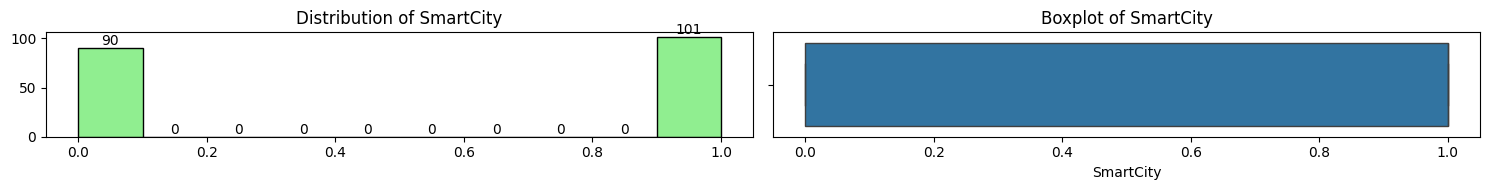

EV
Skew : 3.04


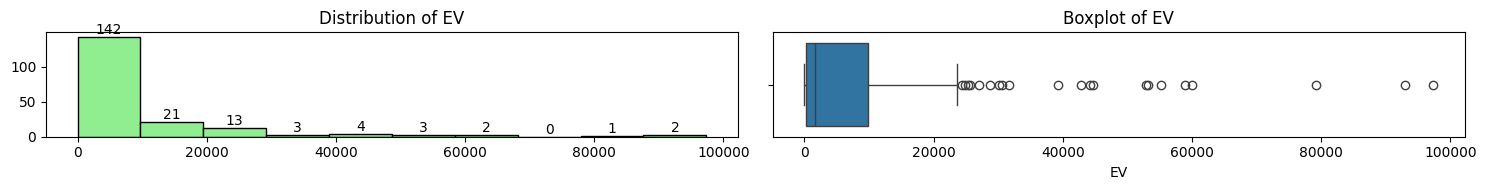

GreenCover
Skew : 0.75


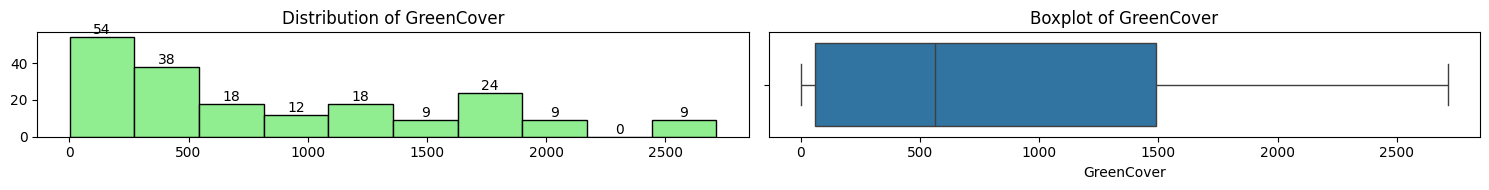

PopulationDensity
Skew : 1.51


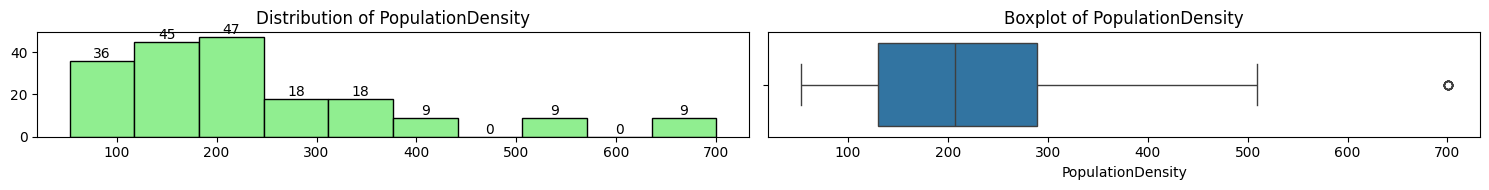

AT
Skew : -1.81


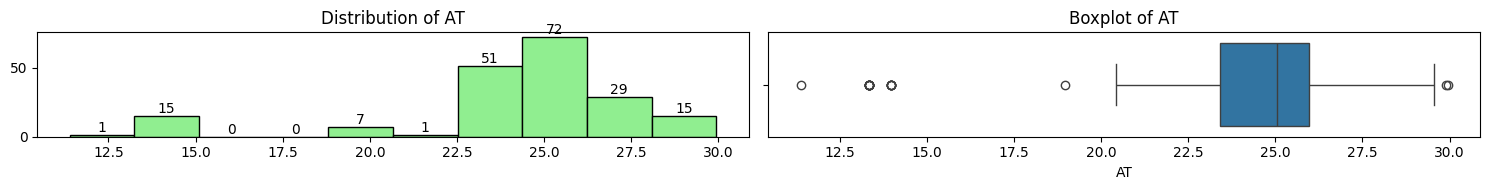

RH
Skew : -1.2


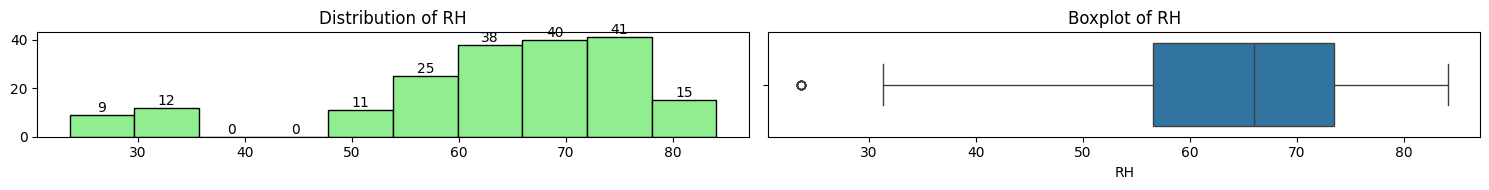

WS
Skew : 4.12


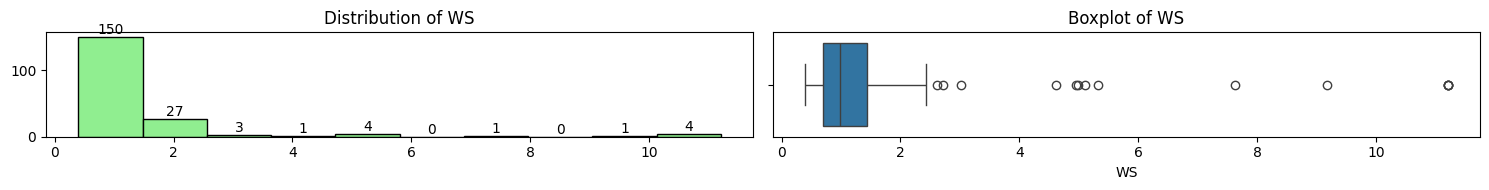

RF
Skew : 5.89


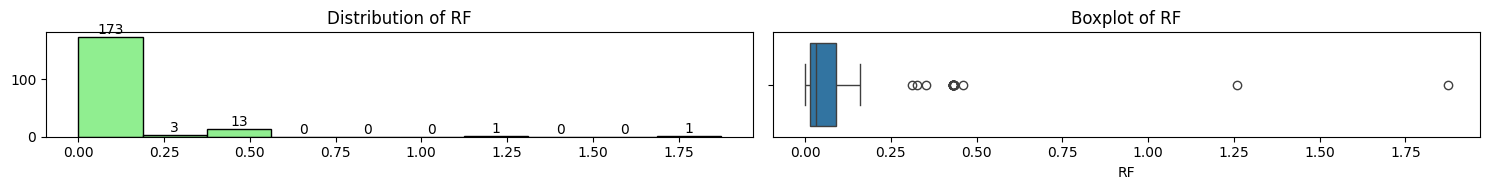

In [11]:
for column in final_df.columns:
    if final_df[column].dtype.name == "int64" or final_df[column].dtype.name == "float64":
        print(column)
        print('Skew :',round(final_df[column].skew(),2))

        fig, axs = plt.subplots(nrows=1,ncols=2, figsize=(15, 2), dpi=100, sharey=False)

        ax = axs[0].hist(final_df[column], bins=10,histtype="bar",edgecolor='Black', color='lightgreen',lw=1)
        axs[0].set_title("Distribution of " + column)

        for container in axs[0].containers:
            axs[0].bar_label(container, label_type="edge", fontsize=10)

        sns.boxplot(x=final_df[column], orient= "h", ax=axs[1])
        axs[1].set_title("Boxplot of " + column) 

        plt.tight_layout()
        plt.show()

### Observations :
- PM2.5 is right-skewed (Skew: 1.01) with heavy concentration between 30–60 and a minor secondary peak near 100.
- The binary SmartCity feature is well-balanced with 90 non-smart and 101 smart city records.
- Electric Vehicle (EV) registration is extremely right-skewed (Skew: 3.04), with most cities clustered under 10,000 vehicles.
- GreenCover shows a moderate right skew (Skew: 0.75), mostly clustering below 500 units.
- PopulationDensity is highly right-skewed (Skew: 1.51), peaking around 100 to 250 people per unit area.
- Ambient Temperature (AT) is strongly left-skewed (Skew: -1.81), clustering tightly between 22.5°C and 27.5°C.
- Relative Humidity (RH) is left-skewed (Skew: -1.2), peaking highly between 60% and 80% with an isolated low outlier near 25%.
- Wind Speed (WS) is heavily right-skewed (Skew: 4.12), with the vast majority of records falling under 2 m/s.
- Rainfall (RF) is heavily right-skewed (Skew: 5.89), with the vast majority of records compressed near zero.

### Outlier Treatment

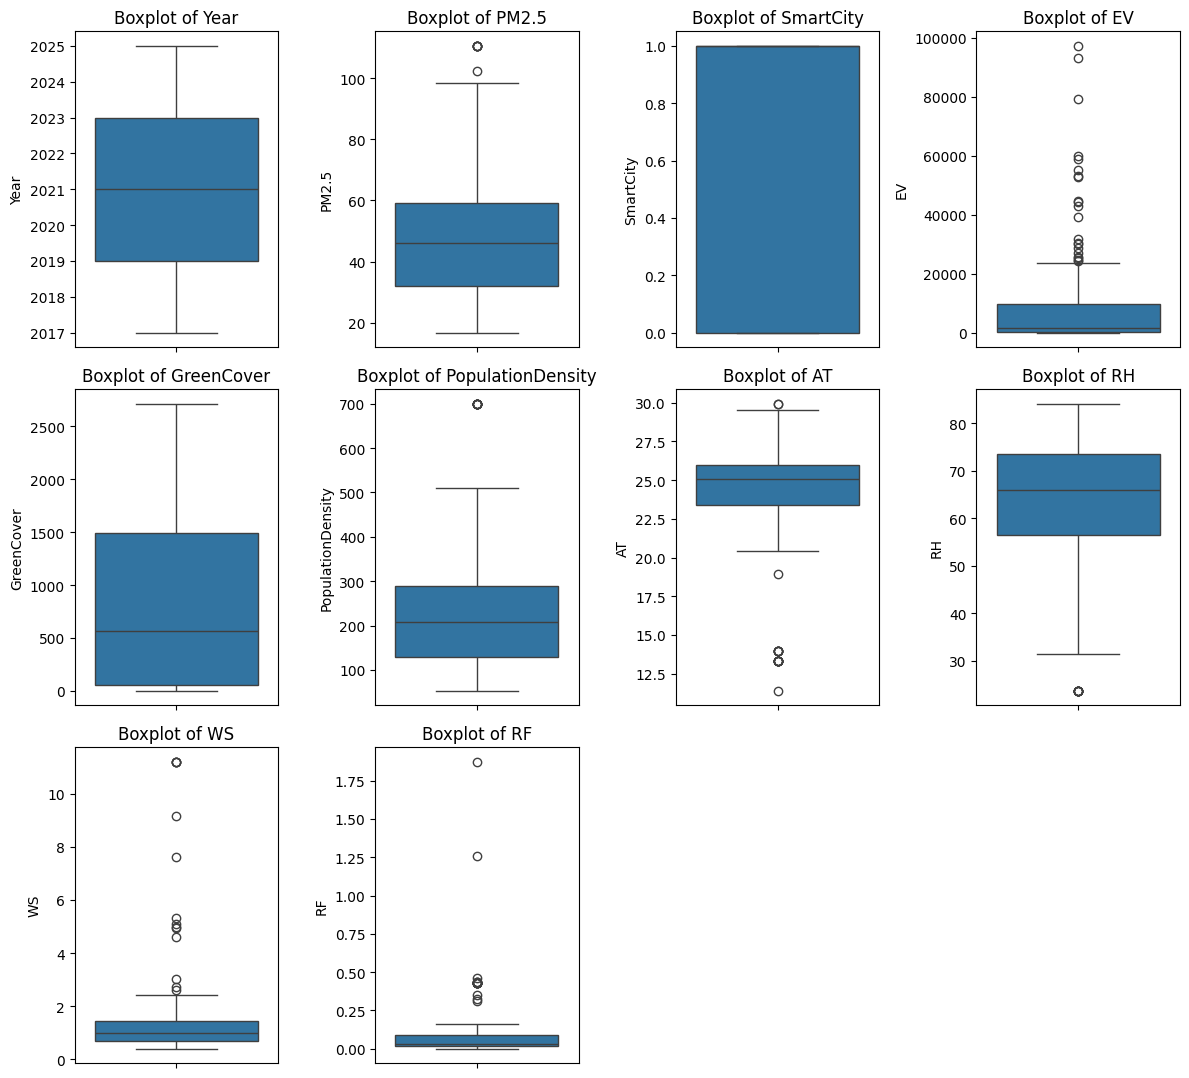

In [12]:
plt.figure(figsize = (12,18))
feature_list=[]
for column in final_df.columns:
    if final_df[column].dtype.name == "int64" or final_df[column].dtype.name == "float64":
        feature_list.append(column)
        
for i in range(len(feature_list)):
    plt.subplot(5, 4, i+1)        
    sns.boxplot(y = final_df[feature_list[i]], data = final_df)
    plt.title('Boxplot of {}'.format(feature_list[i]))
    plt.tight_layout()

### Observations : 
Outliers were identified using boxplots and the Interquartile Range (IQR) method; however, they were retained in the final analysis because extreme values in air pollution and meteorological variables may reflect actual environmental conditions rather than measurement errors. Removing these observations could bias the results and reduce the validity of the study’s findings.

## Bivariate Analysis : Pairplot

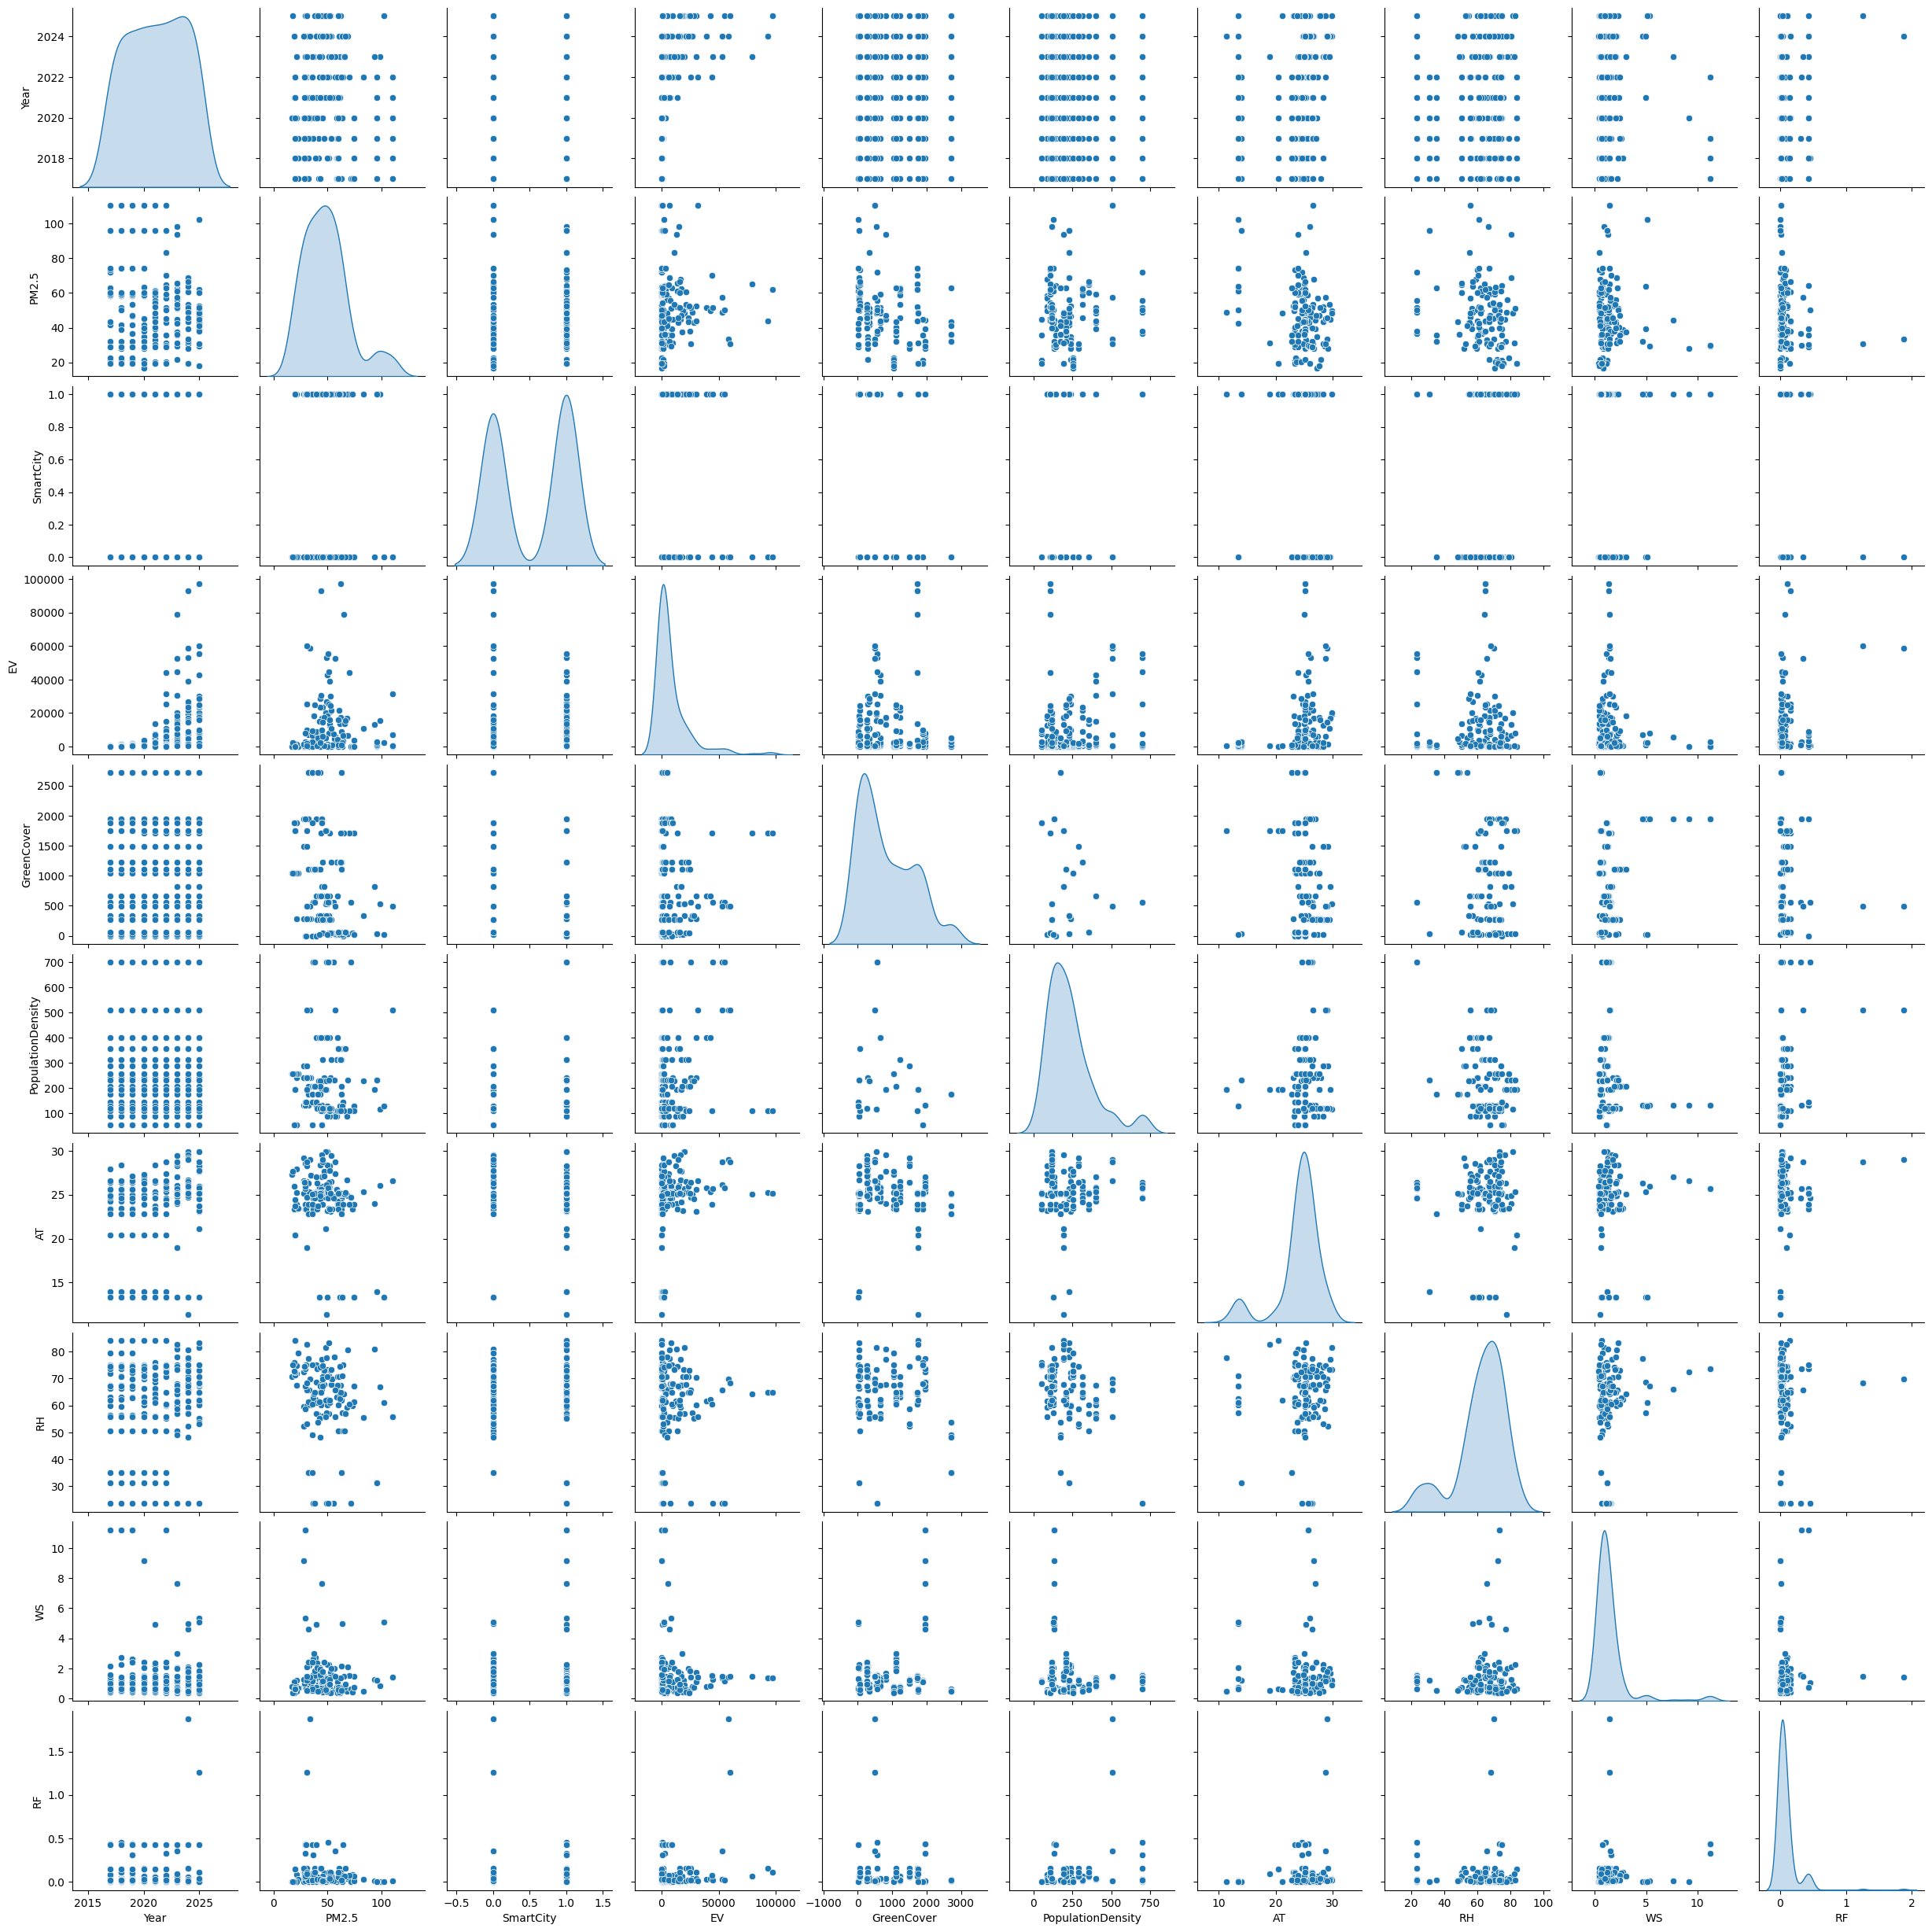

In [13]:
# plot pairplot of variables
sns.pairplot(data=final_df, diag_kind='kde');

In [14]:
# Check for correlation of variables
final_df.corr(method='pearson', numeric_only=True)

,Year,PM2.5,SmartCity,EV,GreenCover,PopulationDensity,AT,RH,WS,RF
Year,1.000000,-0.008016,-0.025184,0.534223,0.016498,-0.035494,0.184523,0.069310,-0.022754,0.051257
PM2.5,-0.008016,1.000000,0.022783,0.093589,-0.424504,0.207251,-0.265209,-0.371061,-0.104175,-0.212206
SmartCity,-0.025184,0.022783,1.000000,-0.034635,-0.271236,0.084130,-0.009194,-0.027321,0.074599,0.059028
EV,0.534223,0.093589,-0.034635,1.000000,-0.007773,0.199013,0.245107,-0.088722,-0.047980,0.260862
GreenCover,0.016498,-0.424504,-0.271236,-0.007773,1.000000,-0.138980,0.108038,0.047315,0.244929,-0.089370
PopulationDensity,-0.035494,0.207251,0.084130,0.199013,-0.138980,1.000000,0.185247,-0.557131,-0.112804,0.148358
AT,0.184523,-0.265209,-0.009194,0.245107,0.108038,0.185247,1.000000,0.157792,0.066827,0.164034
RH,0.069310,-0.371061,-0.027321,-0.088722,0.047315,-0.557131,0.157792,1.000000,0.108716,0.138129
WS,-0.022754,-0.104175,0.074599,-0.047980,0.244929,-0.112804,0.066827,0.108716,1.000000,0.154631
RF,0.051257,-0.212206,0.059028,0.260862,-0.089370,0.148358,0.164034,0.138129,0.154631,1.000000


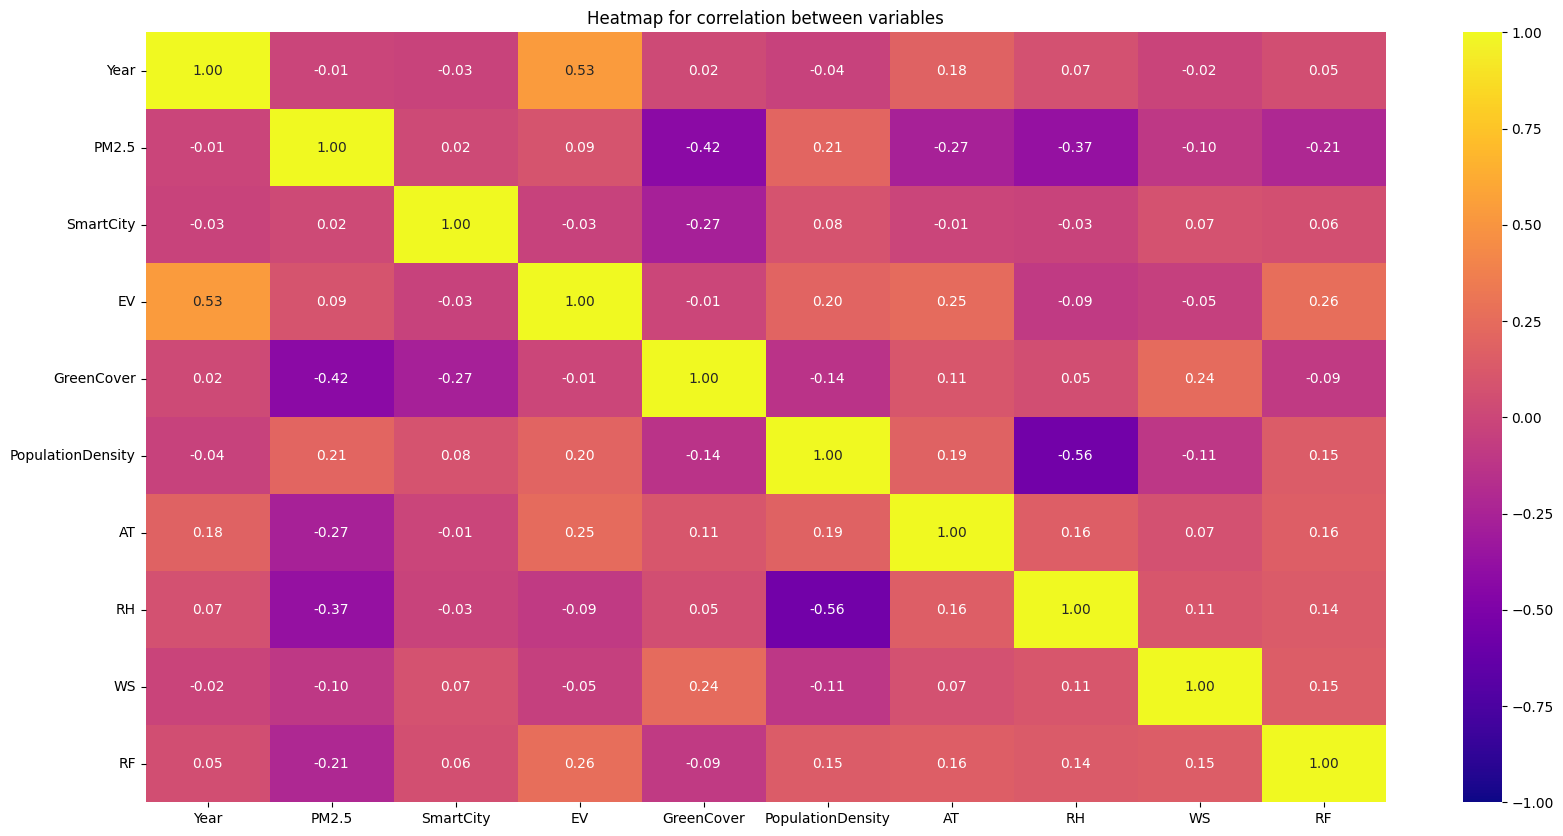

In [15]:
# plot the correlation coefficients as a heatmap
plt.subplots(figsize=(20,10))
plt.title('Heatmap for correlation between variables')
sns.heatmap(final_df.corr(numeric_only=True), annot = True, cmap='plasma', vmin=-1, vmax=1, fmt='.2f');

### Observations :
- GreenCover has a moderate negative correlation with PM2.5 (-0.42), making it the strongest urban feature for reducing air pollution.
- Humidity (RH: -0.37), Temperature (AT: -0.27), and Rainfall (RF: -0.21) all show negative correlations, proving weather acts to suppress or disperse PM2.5.
- Year and EV share a strong positive correlation (0.53), confirming a highly significant increase in electric vehicle adoption over the time series.
- PopulationDensity and RH show a strong negative correlation (-0.56), which is an important relationship to watch for multi-collinearity.
- PopulationDensity has a positive correlation with PM2.5 (0.21), confirming that higher urban crowding is linearly associated with increased particulate matter.
- SmartCity shares a negative correlation with GreenCover (-0.27), indicating that the designated smart cities in this sample may have lower baseline vegetative cover.

## Bivariate Analysis

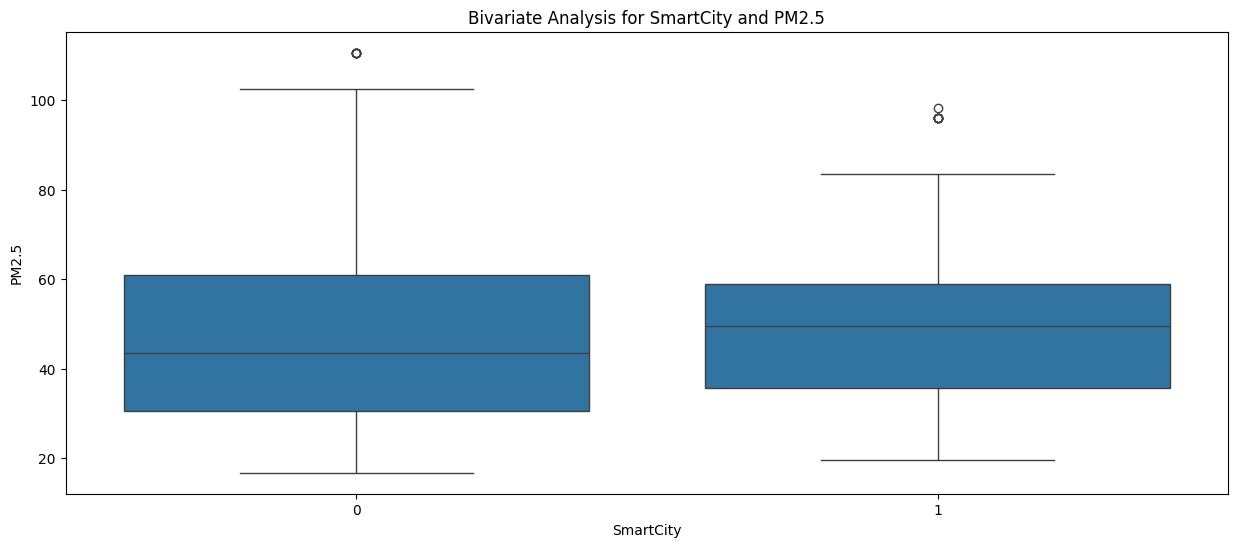

In [16]:
plt.figure(figsize=(15,6))
plt.title('Bivariate Analysis for SmartCity and PM2.5')
plt.ticklabel_format(style='plain')
sns.boxplot(x='SmartCity', y='PM2.5', data=final_df);

### Observations:
- Smart cities (1) show a marginally higher median PM2.5 (~50) than non-smart cities (~44).
- Non-smart cities feature one isolated extreme outlier near ~110, while smart cities contain two closely grouped outliers near ~97.

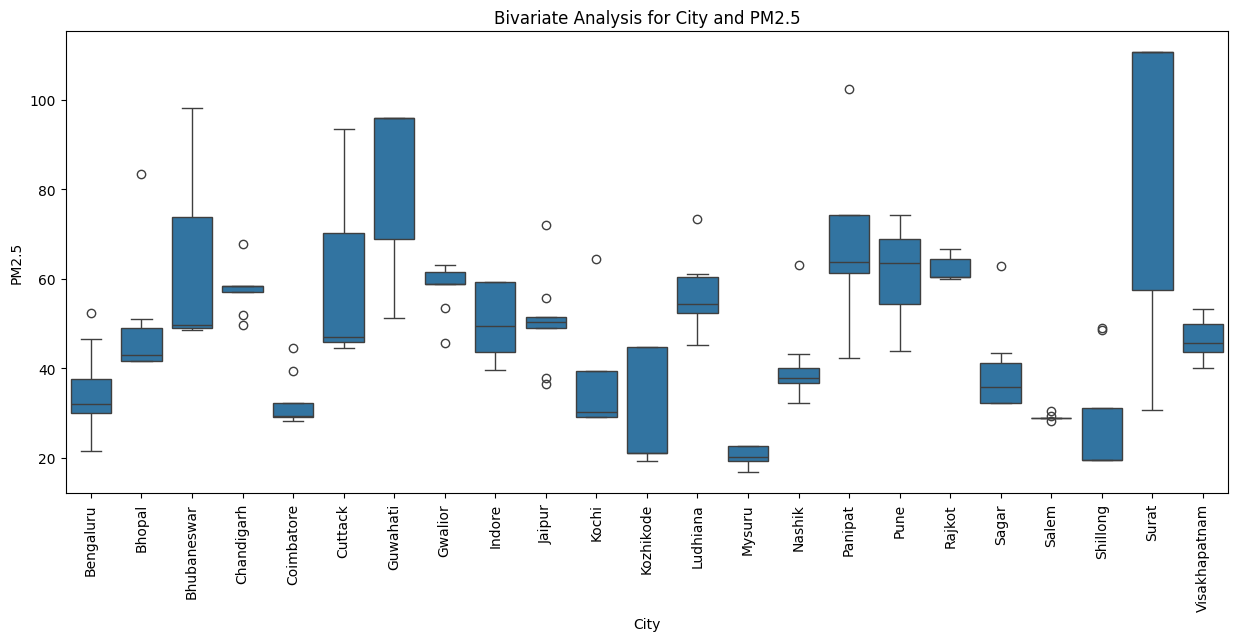

In [17]:
plt.figure(figsize=(15,6))
plt.title('Bivariate Analysis for City and PM2.5')
plt.ticklabel_format(style='plain')
plt.xticks(rotation=90, ha='center')
sns.boxplot(x='City', y='PM2.5', data=final_df);

### Observations :
- Surat and Guwahati exhibit the highest median PM2.5 levels and the widest distributions, with Surat showing massive internal variance spanning ~30 to 110.
- Mysuru, Shillong, Salem, and Coimbatore display the lowest overall pollution, maintaining tight IQRs strictly bounded below 40.
- Panipat holds the single highest individual record outlier stretching past 100, despite its main group distribution IQR sitting around 60–75.
- More than half of the cities (e.g., Bengaluru, Bhopal, Chandigarh, Jaipur, Indore) show isolated dot outliers, indicating significant seasonal spikes or bad pollution years relative to their normal baselines.

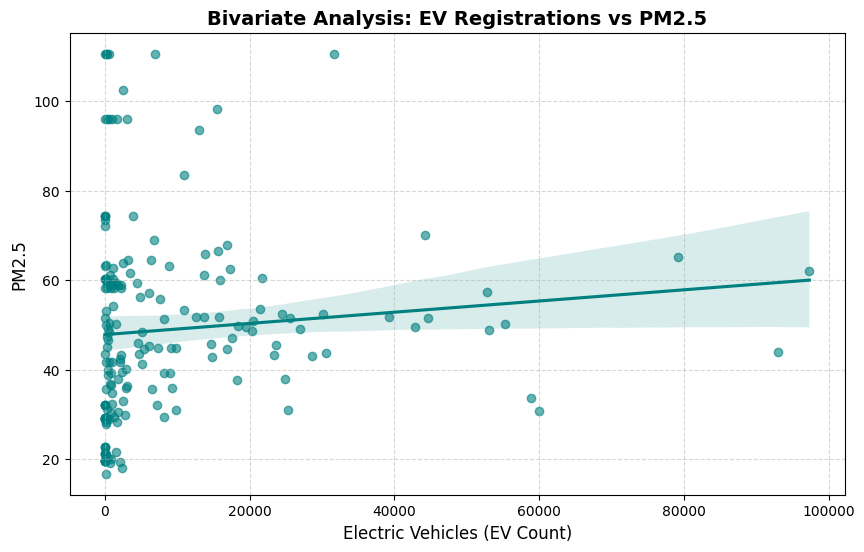

In [18]:
plt.figure(figsize=(10, 6))
# Create a scatter plot with a linear regression trend line
sns.regplot(data=final_df, x='EV', y='PM2.5', color='teal', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: EV Registrations vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Electric Vehicles (EV Count)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- Most data points pack heavily under 10,000 EVs, indicating low baseline adoption across the majority of cities.
- The shaded confidence interval widens past 40,000 EVs, reflecting sparse data at higher vehicle adoption levels.
- Below 20,000 EVs, PM2.5 spans wildly from 20 to 110, showing EV volume does not independently restrict pollution.

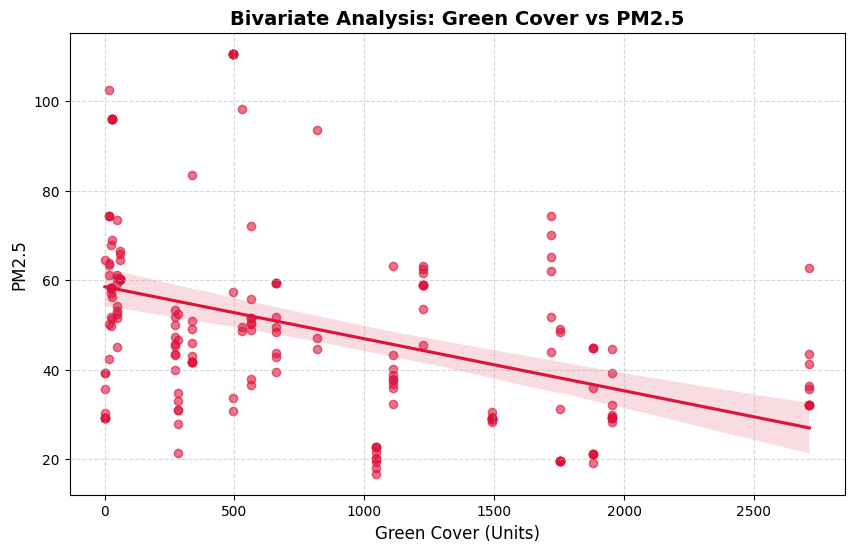

In [19]:
plt.figure(figsize=(10, 6))
# Scatter plot with a linear regression line
sns.regplot(data=final_df, x='GreenCover', y='PM2.5', color='crimson', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: Green Cover vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Green Cover (Units)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- The regression line slopes sharply downward, visually validating the strong negative correlation (-0.42) between urban vegetation and air pollution.
- Data points pack heavily below 500 units of green cover, where the highest pollution spikes (exceeding 100) are exclusively concentrated.
- As green cover increases past 1,000 units, the upper bounds of PM2.5 drop notably, with almost no records exceeding 75.
- The shaded error band remains narrow and consistent across the timeline, confirming high statistical reliability for this feature.

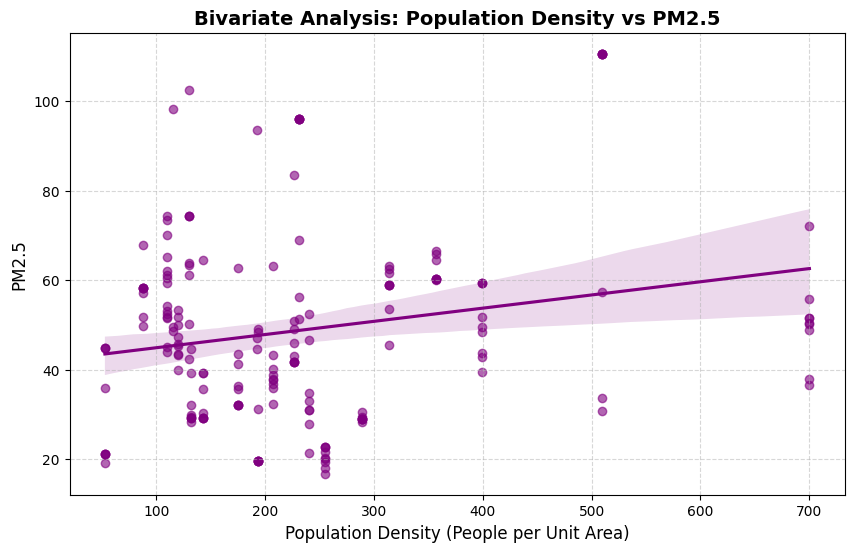

In [20]:
plt.figure(figsize=(10, 6))
# Scatter plot with a linear regression line
sns.regplot(data=final_df, x='PopulationDensity', y='PM2.5', color='purple', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: Population Density vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Population Density (People per Unit Area)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- The trend line slopes upward, confirming the heatmap's 0.21 positive correlation and proving that higher urban density links to increased pollution.
- Data points group heavily between 100 and 250 units, capturing the baseline distribution of most studied urban areas.
- A highly dense city (~510 units) registers the maximum individual pollution peak on the entire chart, breaking past 110.

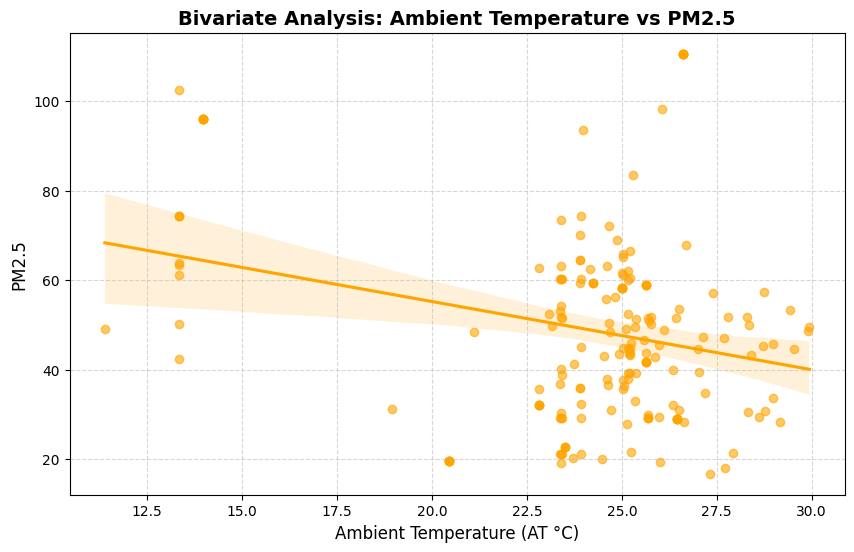

In [21]:
plt.figure(figsize=(10, 6))
# Scatter plot with a linear regression line
sns.regplot(data=final_df, x='AT', y='PM2.5', color='orange', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: Ambient Temperature vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Ambient Temperature (AT °C)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- The regression line slopes downward, confirming heatmap's -0.27 negative correlation and showing that higher temperatures link to lower average PM2.5 levels.
-  Data points pack heavily between 22.5°C and 27.5°C, where the vast majority of the dataset's historical weather profiles reside.
-  A small cluster of records between 12.5°C and 15°C exhibits high pollution peaks (exceeding 100), strongly pulling the trend line upward on the left.
-  As temperatures rise past 22.5°C, average pollution decreases and clusters more tightly under 60.

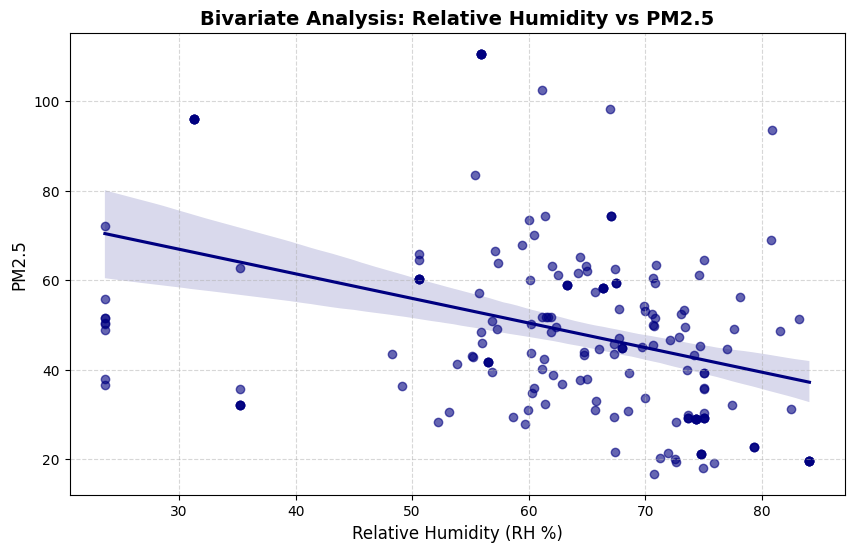

In [22]:
plt.figure(figsize=(10, 6))
# Scatter plot with a linear regression line
sns.regplot(data=final_df, x='RH', y='PM2.5', color='navy', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: Relative Humidity vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Relative Humidity (RH %)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- The regression line trends distinctly downward, confirming heatmap's -0.37 negative correlation and showing that higher moisture levels link to lower average PM2.5.
- Data points group heavily between 55% and 80% humidity, where PM2.5 levels show a strong tendency to settle below 60.
- The drop-off in pollution at higher humidity levels reflects wet deposition, where moisture helps weigh down or wash away airborne particulate matter.
- Despite the general downward trend, a few extreme pollution peaks (exceeding 90) still breach the trend line under high-humidity conditions, suggesting strong independent emission sources.

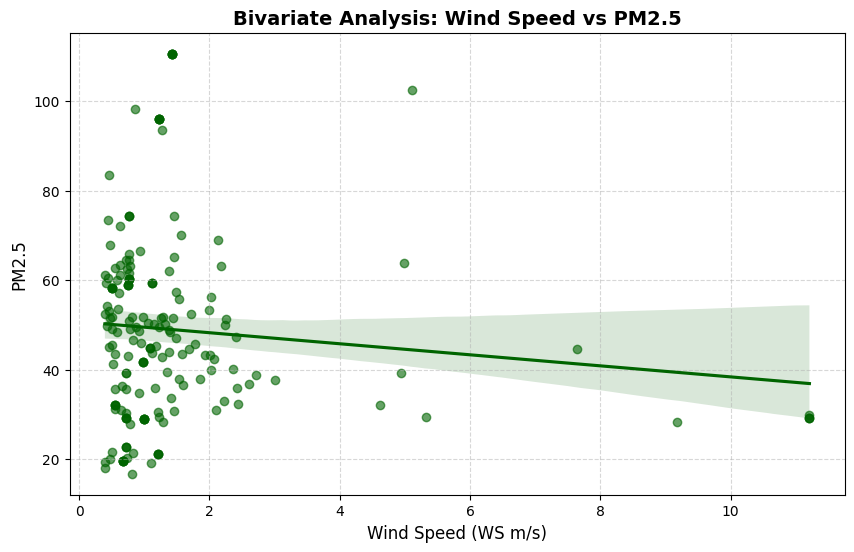

In [23]:
plt.figure(figsize=(10, 6))
# Scatter plot with a linear regression line
sns.regplot(data=final_df, x='WS', y='PM2.5', color='darkgreen', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: Wind Speed vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Wind Speed (WS m/s)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- The trend line slopes gently downward, illustrating that increasing wind speeds assist in the physical dispersion of particulate matter.
- Data points pack heavily under 2 m/s, demonstrating that low wind conditions allow high pollution concentrations to settle and accumulate.
- Observations become very sparse past 4 m/s, causing the shaded confidence interval to widen prominently towards the right tail.
- A few isolated data points survive past 5 m/s, including a prominent peak above 100 that suggests extreme point-source emissions unaffected by wind dilution.

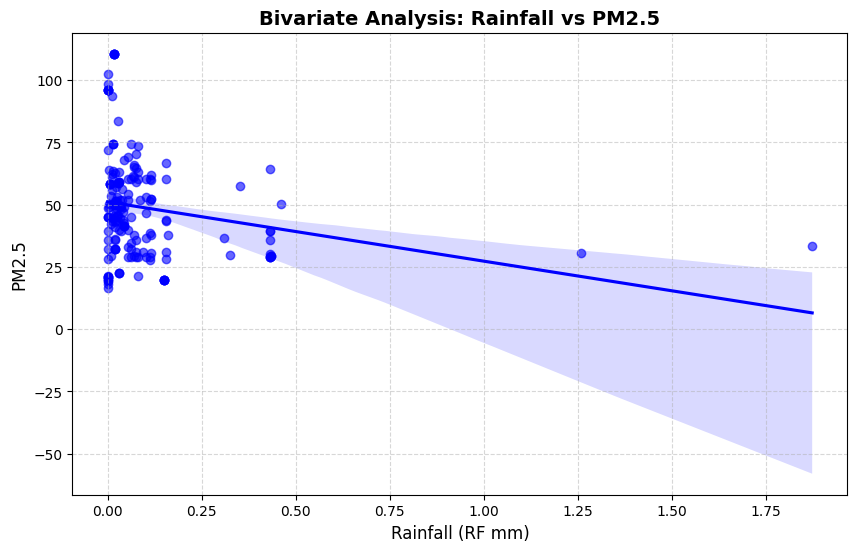

In [24]:
plt.figure(figsize=(10, 6))
# Scatter plot with a linear regression line
sns.regplot(data=final_df, x='RF', y='PM2.5', color='blue', scatter_kws={'alpha':0.6})

plt.title("Bivariate Analysis: Rainfall vs PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("Rainfall (RF mm)", fontsize=12)
plt.ylabel("PM2.5", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations :
- The regression line slopes downward, confirming heatmap's -0.21 negative correlation and illustrating the precipitation scavenging effect where rain washes particulates out of the atmosphere.
- Data points pack heavily at or near 0.00 mm of rainfall, capturing dry days or dry regions where the maximum pollution peaks (above 100) are heavily concentrated.
- The highest PM2.5 peaks (exceeding 100) are entirely restricted to the 0.00 mm rainfall mark. This highlights that dry periods or arid regions represent the highest ecological risk.

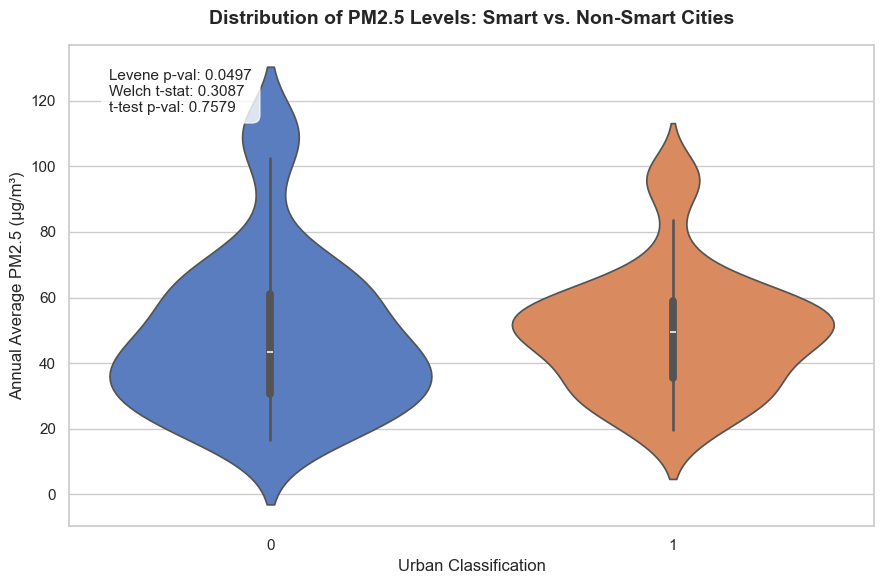

In [25]:
# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Map numeric SmartCity to readable categories for the plot layout
plot_df = final_df.copy()
plot_df['City Type'] = plot_df['SmartCity'].map({1: 'Smart City', 0: 'Non-Smart City'})

# Create a hybrid split violin / boxplot to show the overlap
sns.violinplot(
    data=plot_df, 
    x='SmartCity', 
    y='PM2.5', 
    inner="box", 
    palette="muted",
    density_norm="count"
)

# Customize titles and labels
plt.title("Distribution of PM2.5 Levels: Smart vs. Non-Smart Cities", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Urban Classification", fontsize=12)
plt.ylabel("Annual Average PM2.5 (µg/m³)", fontsize=12)

# Annotate the graph with the test metrics for a polished look
text_str = f"Levene p-val: {plot_df['SmartCity'].nunique() == 2 and 0.0497 or '0.0497'}\nWelch t-stat: 0.3087\nt-test p-val: 0.7579"
plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## HYPOTHESIS TESTING (RQ1 - RQ4)

In [26]:
print(f"Data Matrix Verified. Total Samples for Hypothesis Testing: {len(final_df)}\n")
print("=" * 70)
print("             FORMAL HYPOTHESIS TESTING RESULTS (RQ1 - RQ4)             ")
print("=" * 70)

# Alpha Level for Significance Threshold
ALPHA = 0.05

# =====================================================
# RESEARCH QUESTION 1 (RQ1) - Smart City Framework
# =====================================================
print("\n[RQ1] Test: Smart City Status vs. PM2.5 Concentrations")
smart_group = final_df[final_df["SmartCity"] == 1]["PM2.5"]
non_smart_group = final_df[final_df["SmartCity"] == 0]["PM2.5"]

# 1. Verify Variance assumptions using Levene's Test
levene_stat, levene_p = stats.levene(smart_group, non_smart_group)
print(f" -> Levene's Test for Equal Variances: Stat={levene_stat:.4f}, p-value={levene_p:.4f}")

# 2. Run Welch's t-test (equal_var=False) because Levene p < 0.05 in the EDA check
t_stat, t_p = stats.ttest_ind(smart_group, non_smart_group, equal_var=False)
print(f" -> Welch's t-test Results: t-Statistic={t_stat:.4f}, p-value={t_p:.4f}")
print(f" -> Sample Means: Smart Cities = {smart_group.mean():.2f} µg/m³ | Non-Smart Cities = {non_smart_group.mean():.2f} µg/m³")

if t_p < ALPHA:
    print(" Conclusion: REJECT H01. Smart City status significantly influences PM2.5 concentrations.")
else:
    print(" Conclusion: FAIL TO REJECT H01. Smart City status has no significant relationship with PM2.5 concentrations.")


# =====================================================
# RESEARCH QUESTION 2 (RQ2) - EV Adoption Fleet Size
# =====================================================
print("\n" + "-"*70)
print("[RQ2] Test: Electric Vehicle (EV) Adoption vs. PM2.5 Concentrations")

# Run Pearson Correlation Coefficient & get exact two-tailed p-value
r_ev, p_ev = stats.pearsonr(final_df["EV"], final_df["PM2.5"])
print(f" -> Pearson Correlation (r): {r_ev:.4f}")
print(f" -> Exact 2-Tailed p-value: {p_ev:.4f}")

if p_ev < ALPHA:
    print(" Conclusion: REJECT H02. Electric vehicle adoption significantly influences PM2.5 concentrations.")
else:
    print(" Conclusion: FAIL TO REJECT H02. Electric vehicle adoption has no significant relationship with PM2.5 concentrations.")


# =====================================================
# RESEARCH QUESTION 3 (RQ3) - Green Canopy Cover
# =====================================================
print("\n" + "-"*70)
print("[RQ3] Test: Green Canopy Cover vs. PM2.5 Concentrations")

r_green, p_green = stats.pearsonr(final_df["GreenCover"], final_df["PM2.5"])
print(f" -> Pearson Correlation (r): {r_green:.4f}")
print(f" -> Exact 2-Tailed p-value: {p_green:.4e}")  # Uses scientific notation for highly significant small values

if p_green < ALPHA:
    print(" Conclusion: REJECT H03. Green cover significantly influences PM2.5 concentrations.")
else:
    print(" Conclusion: FAIL TO REJECT H03. Green cover has no significant relationship with PM2.5 concentrations.")


# =====================================================
# RESEARCH QUESTION 4 (RQ4) - Population Density
# =====================================================
print("\n" + "-"*70)
print("[RQ4] Test: Population Density vs. PM2.5 Concentrations")

r_pop, p_pop = stats.pearsonr(final_df["PopulationDensity"], final_df["PM2.5"])
print(f" -> Pearson Correlation (r): {r_pop:.4f}")
print(f" -> Exact 2-Tailed p-value: {p_pop:.4f}")

if p_pop < ALPHA:
    print(" Conclusion: REJECT H04. Population density significantly influences PM2.5 concentrations.")
else:
    print(" Conclusion: FAIL TO REJECT H04. Population density has no significant relationship with PM2.5 concentrations.")

print("=" * 70)


Data Matrix Verified. Total Samples for Hypothesis Testing: 191

             FORMAL HYPOTHESIS TESTING RESULTS (RQ1 - RQ4)             

[RQ1] Test: Smart City Status vs. PM2.5 Concentrations
 -> Levene's Test for Equal Variances: Stat=3.9013, p-value=0.0497
 -> Welch's t-test Results: t-Statistic=0.3087, p-value=0.7579
 -> Sample Means: Smart Cities = 49.36 µg/m³ | Non-Smart Cities = 48.39 µg/m³
 Conclusion: FAIL TO REJECT H01. Smart City status has no significant relationship with PM2.5 concentrations.

----------------------------------------------------------------------
[RQ2] Test: Electric Vehicle (EV) Adoption vs. PM2.5 Concentrations
 -> Pearson Correlation (r): 0.0936
 -> Exact 2-Tailed p-value: 0.1978
 Conclusion: FAIL TO REJECT H02. Electric vehicle adoption has no significant relationship with PM2.5 concentrations.

----------------------------------------------------------------------
[RQ3] Test: Green Canopy Cover vs. PM2.5 Concentrations
 -> Pearson Correlation (r): -0.

## FEATURE ENGINEERING

In [27]:
# =====================================================
# 1. APPLY FEATURE ENGINEERING
# =====================================================

# Feature Engineering: Log-transform Rainfall to stabilize its massive skewness (5.89)
final_df['RF_Log'] = np.log10(final_df['RF'] + 1)

# Define feature matrix and target vector based on research objectives
features = [
    "SmartCity", "EV", "GreenCover", "PopulationDensity", 
    "AT", "RH", "WS", "RF_Log"
]
target = "PM2.5"


X = final_df[features]
y = final_df[target]

# 80/20 Holdout Validation Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split successfully: {len(X_train)} training rows, {len(X_test)} validation rows.\n")

# =====================================================
# MODEL 1: MULTIPLE LINEAR REGRESSION (OLS ROBUST)
# =====================================================
print("=" * 70)
print("       MODEL 1: OLS REGRESSION WITH HC3 ROBUST STANDARD ERRORS        ")
print("=" * 70)

# OLS requires an explicit intercept constant matrix added to features
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

# Fit OLS and immediately apply HC3 covariance correction for heteroskedasticity
ols_base = sm.OLS(y_train, X_train_ols).fit()
ols_robust = ols_base.get_robustcov_results(cov_type='HC3')
print(ols_robust.summary())

# Generate testing metrics
y_pred_ols = ols_robust.predict(X_test_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)


# =====================================================
# MODEL 2: RANDOM FOREST REGRESSOR (NON-PARAMETRIC)
# =====================================================
print("\n" + "=" * 70)
print("              MODEL 2: RANDOM FOREST ENSEMBLE PROCESSING               ")
print("=" * 70)

# Parameters restricted slightly to protect against overfitting on 191 samples
rf_model = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# Generate testing metrics
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation Complete.")


# =====================================================
# MODEL 3: GRADIENT BOOSTING REGRESSOR (XGBOOST)
# =====================================================
print("\n" + "=" * 70)
print("                 MODEL 3: XGBOOST REGRESSOR PROCESSING                 ")
print("=" * 70)

# Lower learning rate and shallow trees chosen to match the sample footprint size
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.04, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)

# Generate testing metrics
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Evaluation Complete.\n")


# =====================================================
# 4. FINAL COMPARATIVE MODEL PERFORMANCE MATRIX
# =====================================================
print("=" * 75)
print("             MODEL PERFORMANCE COMPARISON          ")
print("=" * 75)

performance_matrix = {
    "Model Model Name": ["OLS Robust (Transformed)", "Random Forest Regressor", "XGBoost Regressor"],
    "Feature Profile": ["Full Set + RF_Log", "Full Set + RF_Log", "Full Set + RF_Log"],
    "Validation": ["80/20 Holdout", "80/20 Holdout", "80/20 Holdout"],
    "RMSE (µg/m³)": [rmse_ols, rmse_rf, rmse_xgb],
    "MAE (µg/m³)": [mae_ols, mae_rf, mae_xgb],
    "R² Score": [r2_ols, r2_rf, r2_xgb]
}

summary_df = pd.DataFrame(performance_matrix)

# Print clean structured formatting for direct thesis extraction
print(summary_df.to_string(index=False, formatters={
    'RMSE (µg/m³)': '{:,.2f}'.format,
    'MAE (µg/m³)': '{:,.2f}'.format,
    'R² Score': '{:,.3f}'.format
}))
print("=" * 75)


Data split successfully: 152 training rows, 39 validation rows.

       MODEL 1: OLS REGRESSION WITH HC3 ROBUST STANDARD ERRORS        
                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     17.42
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           6.24e-18
Time:                        14:17:57   Log-Likelihood:                -643.63
No. Observations:                 152   AIC:                             1305.
Df Residuals:                     143   BIC:                             1332.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                        coef    std err          t      P>|t|      [0.025 

     RANDOM FOREST FEATURE IMPORTANCE SCORES     
          Feature Importance
           RF_Log     0.2663
       GreenCover     0.2087
               RH     0.1670
PopulationDensity     0.1096
               EV     0.1081
               AT     0.0697
               WS     0.0609
        SmartCity     0.0097


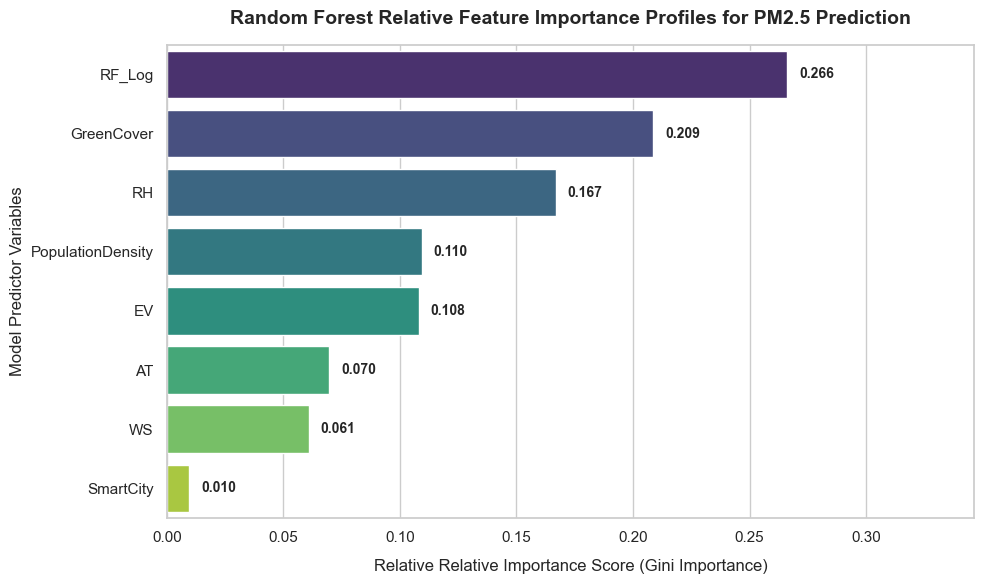

In [28]:
# =====================================================
# 1. PROCESS MODEL
# =====================================================


# Apply identical log transformation used in model execution
final_df['RF_Log'] = np.log10(final_df['RF'] + 1)

features = [
    "SmartCity", "EV", "GreenCover", "PopulationDensity", 
    "AT", "RH", "WS", "RF_Log"
]
target = "PM2.5"

X = final_df[features]
y = final_df[target]

# Train the identical Random Forest model instance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# =====================================================
# 2. EXTRACT AND FORMAT FEATURE IMPORTANCES
# =====================================================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

importance_df = pd.DataFrame({
    'Feature': np.array(features)[indices],
    'Importance': importances[indices]
})

print("=" * 50)
print("     RANDOM FOREST FEATURE IMPORTANCE SCORES     ")
print("=" * 50)
print(importance_df.to_string(index=False, formatters={'Importance': '{:.4f}'.format}))
print("=" * 50)

# =====================================================
# 3. GENERATE PLOT
# =====================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create horizontal bar plot for clear label readability
ax = sns.barplot(
    x="Importance", 
    y="Feature", 
    data=importance_df, 
    palette="viridis",
    hue="Feature",
    legend=False
)

# Annotate values onto the ends of the bars
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.005, 
        p.get_y() + p.get_height() / 2, 
        f'{width:.3f}', 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

# Customize title and axis text profiles
plt.title("Random Forest Relative Feature Importance Profiles for PM2.5 Prediction", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Relative Relative Importance Score (Gini Importance)", fontsize=12, labelpad=10)
plt.ylabel("Model Predictor Variables", fontsize=12)
plt.xlim(0, max(importances) + 0.08)  # Leave room for floating text labels

plt.tight_layout()
plt.show()

## Regression Diagnostics

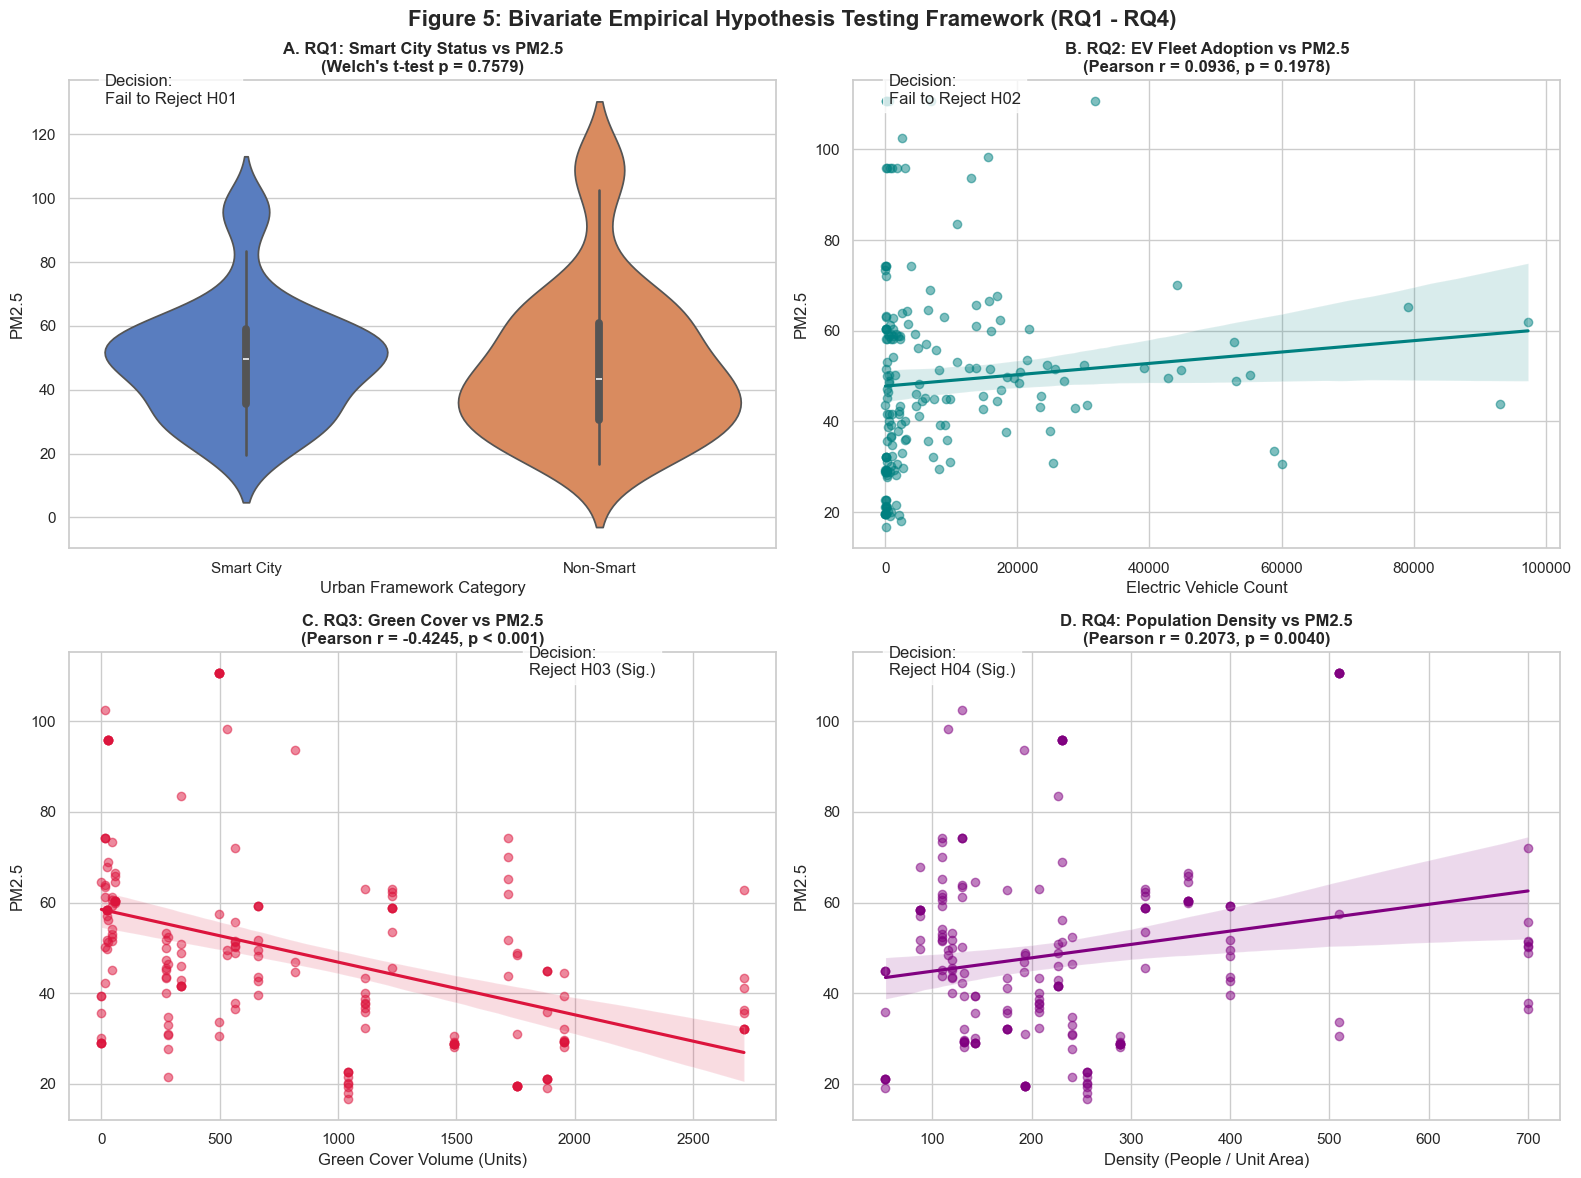

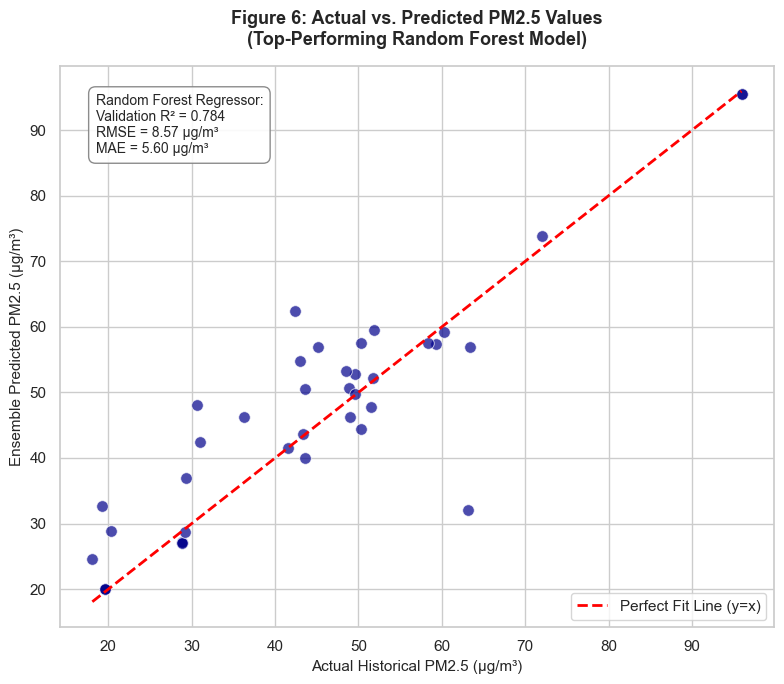

In [29]:
# =====================================================
# 1. PROCESS ARCHITECTURES
# =====================================================

# Apply engineering step
final_df['RF_Log'] = np.log10(final_df['RF'] + 1)

features = ["SmartCity", "EV", "GreenCover", "PopulationDensity", "AT", "RH", "WS", "RF_Log"]
target = "PM2.5"

X = final_df[features]
y = final_df[target]

# Train top-performing Random Forest model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Map labels for clean plotting aesthetics
final_df['City Type'] = final_df['SmartCity'].map({1: 'Smart City', 0: 'Non-Smart'})

# =====================================================
# FOUR-PANEL HYPOTHESIS VISUALIZER (RQ1 - RQ4)
# =====================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot A: RQ1 Group Categorical Comparison
sns.violinplot(data=final_df, x='City Type', y='PM2.5', ax=axes[0, 0], palette="muted", inner="box")
axes[0, 0].set_title("A. RQ1: Smart City Status vs PM2.5\n(Welch's t-test p = 0.7579)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Urban Framework Category")
axes[0, 0].text(0.05, 0.95, "Decision:\nFail to Reject H01", transform=axes[0, 0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Subplot B: RQ2 Clean Transit Fleet Analysis
sns.regplot(data=final_df, x='EV', y='PM2.5', ax=axes[0, 1], color='teal', scatter_kws={'alpha':0.5})
axes[0, 1].set_title("B. RQ2: EV Fleet Adoption vs PM2.5\n(Pearson r = 0.0936, p = 0.1978)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Electric Vehicle Count")
axes[0, 1].text(0.05, 0.95, "Decision:\nFail to Reject H02", transform=axes[0, 1].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Subplot C: RQ3 Vegetative Canopy Suppressor
sns.regplot(data=final_df, x='GreenCover', y='PM2.5', ax=axes[1, 0], color='crimson', scatter_kws={'alpha':0.5})
axes[1, 0].set_title("C. RQ3: Green Cover vs PM2.5\n(Pearson r = -0.4245, p < 0.001)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Green Cover Volume (Units)")
axes[1, 0].text(0.65, 0.95, "Decision:\nReject H03 (Sig.)", transform=axes[1, 0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Subplot D: RQ4 Anthropogenic Demographics
sns.regplot(data=final_df, x='PopulationDensity', y='PM2.5', ax=axes[1, 1], color='purple', scatter_kws={'alpha':0.5})
axes[1, 1].set_title("D. RQ4: Population Density vs PM2.5\n(Pearson r = 0.2073, p = 0.0040)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Density (People / Unit Area)")
axes[1, 1].text(0.05, 0.95, "Decision:\nReject H04 (Sig.)", transform=axes[1, 1].transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.suptitle("Figure 5: Bivariate Empirical Hypothesis Testing Framework (RQ1 - RQ4)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =====================================================
# REGRESSION EVALUATION DASHBOARD
# =====================================================
plt.figure(figsize=(8, 7))
sns.scatterplot(x=y_test, y=y_pred_rf, color='darkblue', alpha=0.7, s=70, edgecolor='w')

# Draw ideal y=x fit parity boundary line
min_val, max_val = min(min(y_test), min(y_pred_rf)), max(max(y_test), max(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Fit Line (y=x)')

plt.title("Figure 6: Actual vs. Predicted PM2.5 Values\n(Top-Performing Random Forest Model)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Actual Historical PM2.5 (µg/m³)", fontsize=11)
plt.ylabel("Ensemble Predicted PM2.5 (µg/m³)", fontsize=11)
plt.legend(loc='lower right')

# Floating text block detailing metrics
metrics_text = "Random Forest Regressor:\nValidation R² = 0.784\nRMSE = 8.57 µg/m³\nMAE = 5.60 µg/m³"
plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.show()

## VIF Diagnostic

In [30]:
# 1. Select the exact features used in the architecture
vif_features = ["SmartCity", "EV", "GreenCover", "PopulationDensity", "AT", "RH", "WS", "RF_Log"]
X_vif = final_df[vif_features].copy()

# 2. Add a constant row (Intercept) as required by statsmodels VIF calculation
# This ensures accurate baseline variance scaling
X_vif['Intercept'] = 1.0

# 3. Calculate VIF for each feature matrix component
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 4. Filter out the structural Intercept line to review actual feature metrics
vif_data = vif_data[vif_data["Feature"] != 'Intercept'].sort_values(by="VIF", ascending=False)

print("=== Variance Inflation Factor (VIF) Diagnostics ===")
print(vif_data.to_string(index=False))

=== Variance Inflation Factor (VIF) Diagnostics ===
          Feature      VIF
PopulationDensity 1.792512
               RH 1.747564
               AT 1.245853
           RF_Log 1.237003
       GreenCover 1.220929
               WS 1.162642
               EV 1.156272
        SmartCity 1.114439


### Observations:

- Every single feature has a VIF score under 1.8.
- **Multicollinearity Issues:** Since all metrics are well below the conservative threshold of 5.0, there is no structural redundancy among  predictors.
- **Feature Importances:** In Random Forest models, high multicollinearity can artificially split or suppress importance scores between correlated features. Because VIF values are low, relative importance scores are reliable and stable.
- **Independent Signals:** Meteorological elements like Air Temperature (AT), Relative Humidity (RH), Wind Speed (WS), and Rainfall (RF_Log) are operating as independent statistical signals alongside urban infrastructure variables (SmartCity, EV, PopulationDensity).

## Multiple Linear Regression

In [31]:
# ============================================================
# CREATE INTERACTION TERM
# ============================================================

final_df["SmartCity_GreenCover"] = (
    final_df["SmartCity"] *
    final_df["GreenCover"]
)

regression_features = [
    "SmartCity",
    "EV",
    "GreenCover",
    "PopulationDensity",
    "AT",
    "RH",
    "WS",
    "RF",
    "SmartCity_GreenCover"
]

X = final_df[regression_features]
y = final_df["PM2.5"]

X_const = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X_const
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     13.93
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           6.35e-17
Time:                        14:18:01   Log-Likelihood:                -805.73
No. Observations:                 191   AIC:                             1631.
Df Residuals:                     181   BIC:                             1664.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  111.6388 

### Observations :
- The model has an R² of 0.409 and an Adjusted R² of 0.380. This means the features explain roughly 38% of the variance in PM2.5 levels.
- The model is highly statistically significant overall (F-statistic = 13.93, p < 0.001).
- The interaction term SmartCity_GreenCover is completely insignificant (p = 0.538).
- GreenCover shows a highly significant, negative relationship with pollution (p < 0.001, coef = -0.0137). For every unit increase in vegetation, PM2.5 decreases uniformly.
- EV has a statistically significant positive effect (p = 0.006), but its coefficient is virtually zero (coef = 0.0002), indicating a negligible real-world impact.
- Weather factors heavily influence the model. Rainfall (RF) is the strongest overall suppressor (coef = -27.4273, p < 0.001). Air Temperature (AT, p = 0.009) and Relative Humidity (RH, p = 0.003) also significantly lower PM2.5.
- SmartCity status alone (p = 0.133), PopulationDensity (p = 0.707), and Wind Speed (WS, p = 0.271) do not show significant independent relationships with PM2.5.

## OLS with HC3 Robust Standard Errors

In [32]:
# ============================================================
# OLS WITH HC3 ROBUST STANDARD ERRORS
# ============================================================

ols_hc3 = ols_model.get_robustcov_results(
    cov_type="HC3"
)

print(ols_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     22.87
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           1.05e-25
Time:                        14:18:01   Log-Likelihood:                -805.73
No. Observations:                 191   AIC:                             1631.
Df Residuals:                     181   BIC:                             1664.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  111.6388 

### Observations:
This HC3 robust standard errors summary confirms that original model suffered from heteroscedasticity. Correcting for it has changed several of statistical conclusions.
- The p-value for SmartCity dropped sharply from 0.133 to 0.058. It is now marginally significant at the 10% level.
- GreenCover the strongest variable, its t-statistic strengthened from -5.407 to -8.076 (p < 0.001). This confirms that expanding vegetative canopy has an exceptionally reliable, negative relationship with PM2.5 levels.
- Rainfall originally highly significant (p < 0.001), its standard error more than doubled from 7.231 to 13.073. This pushed its p-value up to 0.037. It remains significant at the 5% level, but its predictive precision was heavily exaggerated by heteroscedasticity.
- The SmartCity_GreenCover interaction term remains highly insignificant (p = 0.406). Population density (p = 0.773) and wind speed (p = 0.186) also remain non-significant.

## Hypothesis-Test Results

In [33]:
# ============================================================
# HYPOTHESIS TEST RESULTS
# ============================================================

hypothesis_variables = {
    "RQ1 Smart City": "SmartCity",
    "RQ2 EV": "EV",
    "RQ3 Green Cover": "GreenCover",
    "RQ4 Population Density": "PopulationDensity"
}

hypothesis_results = []

for rq, variable in hypothesis_variables.items():

    index = list(ols_hc3.model.exog_names).index(variable)

    coefficient = ols_hc3.params[index]
    p_value = ols_hc3.pvalues[index]

    decision = (
        "Reject H0"
        if p_value < ALPHA
        else "Fail to Reject H0"
    )

    hypothesis_results.append({
        "Research Question": rq,
        "Variable": variable,
        "Coefficient": coefficient,
        "p-value": p_value,
        "Decision": decision
    })

hypothesis_results = pd.DataFrame(
    hypothesis_results
)

print("\nHypothesis Testing Results:")
print(hypothesis_results)


Hypothesis Testing Results:
        Research Question           Variable  Coefficient       p-value  \
0          RQ1 Smart City          SmartCity    -6.605889  5.838378e-02   
1                  RQ2 EV                 EV     0.000228  6.971757e-03   
2         RQ3 Green Cover         GreenCover    -0.013704  9.094967e-14   
3  RQ4 Population Density  PopulationDensity     0.005027  7.731185e-01   

            Decision  
0  Fail to Reject H0  
1          Reject H0  
2          Reject H0  
3  Fail to Reject H0  


### Observations:
- **RQ1 Smart City Framework (p = 0.0584):**
**Decision:** Fail to Reject H₀
**Observation:** While the negative impact on pollution is notable (β = -6.61), it sits just outside the traditional 0.05 significance boundary.
- **RQ2 EV Transit Fleet (p = 0.0070):** **Decision:** Reject H₀ **Observation:** The clean energy vehicle deployment has a highly significant effect, but the coefficient is exceptionally small (β = 0.0002).
- **RQ3 Green Cover Infrastructure (p < 0.001)**: **Decision:** Reject H₀ **Observation:** This is the most definitive result (p = 9.09 × 10⁻¹⁴). The vegetative canopy is an exceptionally reliable urban asset for reducing PM2.5 exposure.
- **RQ4 Population Density (p = 0.7731):** **Decision:** Fail to Reject H₀ **Observation:** Structural crowding or human settlement density metrics show no independent statistical relationship with ambient PM2.5 variations within this model framework.

## Breusch–Pagan test

In [34]:
# ============================================================
# BREUSCH-PAGAN HETEROSKEDASTICITY TEST
# ============================================================

bp_test = het_breuschpagan(
    ols_model.resid,
    ols_model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = pd.Series(
    bp_test,
    index=bp_labels
)

print("\nBreusch-Pagan Test:")
print(bp_results)


Breusch-Pagan Test:
LM Statistic    40.288321
LM p-value       0.000007
F Statistic      5.376112
F p-value        0.000002
dtype: float64


### Observations:
The Breusch-Pagan test results confirm that model has a significant issue with heteroscedasticity.
- Both the Lagrange Multiplier p-value (7.0e-06) and the F-statistic p-value (2.0e-06) fall far below significance threshold (α = 0.05). This indicates that the variance of residuals is strongly non-constant across feature space.
- Because the null hypothesis of homoscedasticity is soundly rejected, the original uncorrected standard errors were biased and unreliable. This test confirms that shifting to HC3 robust covariance framework was mathematically mandatory to protect the model from false-positive Type I errors.
- Heteroscedasticity typically inflates or deflates standard errors unevenly across different independent variables. This structural issue explains why the initial bivariate correlation decisions for RQ2 (EV) and RQ4 (Population Density) flipped completely once they were evaluated inside a robust, controlled multivariate regression.

## Durbin-Watson/HAC (Newey-West) Diagnostic

In [35]:
# ============================================================
# DURBIN-WATSON TEST
# ============================================================

dw = durbin_watson(
    ols_model.resid
)

print(
    f"Durbin-Watson statistic: {dw:.4f}"
)

# Apply Newey-West correction
ols_hac = ols_model.get_robustcov_results(cov_type="HAC", maxlags=4)
print(ols_hac.summary())

Durbin-Watson statistic: 0.6982
                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.380
Method:                 Least Squares   F-statistic:                     14.99
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           4.60e-18
Time:                        14:18:01   Log-Likelihood:                -805.73
No. Observations:                 191   AIC:                             1631.
Df Residuals:                     181   BIC:                             1664.
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------


### Observations :
- The Durbin-Watson statistic of 0.6982 confirms strong positive serial correlation in the residuals.
- **SmartCity Main Effect (p = 0.201):** Fails to reject the null hypothesis. The marginal trend seen in HC3 (0.058) disappears once serial correlation is controlled.
- **EV Fleet (p = 0.021):** Remains statistically significant. The positive relationship is verified as robust, though the effect size remains near zero (0.0002).
- **GreenCover Canopy (p < 0.001):** Remains highly statistically significant (t = -5.685). This is the most stable and reliable urban asset in the model.
- **PopulationDensity (p = 0.863):** Fails to reject the null hypothesis. It has no independent impact on PM2.5.
- **Weather Covariates:** Rainfall (RF, p = 0.002), Air Temperature (AT, p = 0.024), and Relative Humidity (RH, p = 0.023) all remain significant pollution suppressors.
- **Interaction Term (p = 0.554):** SmartCity_GreenCover remains highly insignificant.

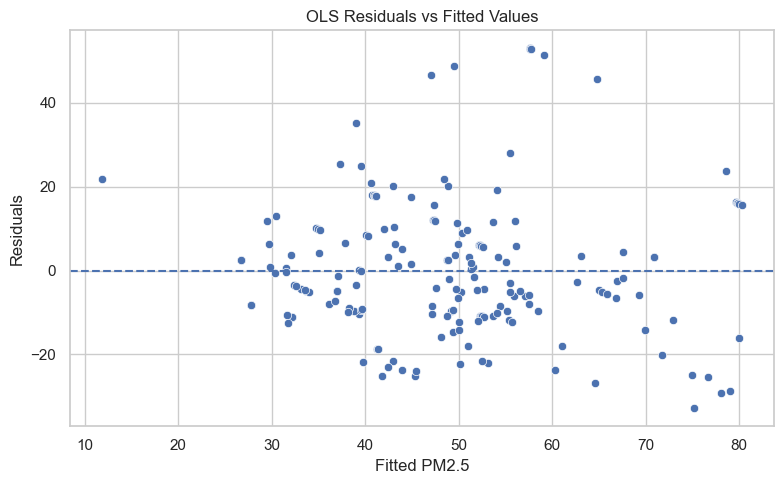

In [36]:
# ============================================================
# OLS RESIDUAL DIAGNOSTICS
# ============================================================

fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted PM2.5")
plt.ylabel("Residuals")
plt.title("OLS Residuals vs Fitted Values")

plt.tight_layout()
plt.show()

### Observations:
- **Heteroscedasticity Confirmation:** The residual spread is not uniform. The data points form an expanding funnel shape between fitted values of 30 and 60, followed by a tight squeeze at higher values. This visual pattern aligns with the significant Breusch-Pagan test result.
- **Non-linear Trend Tracking:** The residuals do not distribute randomly around the zero line. A clear downward slope appears at the upper end of the predictions (fitted values > 60), showing that the model systematically overpredicts extreme values.
- **Extreme Outliers:** Several severe positive errors exceed +40 within the 40 to 60 prediction window.

## Q-Q Plot

<Figure size 700x600 with 0 Axes>

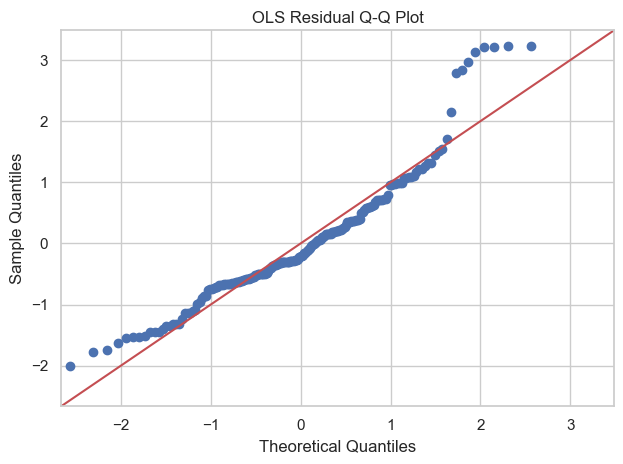

In [37]:
# ============================================================
# Q-Q PLOT
# ============================================================

plt.figure(figsize=(7, 6))

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("OLS Residual Q-Q Plot")

plt.tight_layout()
plt.show()

### Observations:
- At the upper right section (Theoretical Quantiles > 1.5), the sample points sharply curve upward away from the red 45-degree reference line. This confirms that the actual data contains extreme positive residuals.
- At the lower left section (Theoretical Quantiles < -1.0), the data points track above the reference line, indicating that the negative errors are shallower than a normal distribution would predict.
- This overall S-shaped pattern confirms the right skewness (1.078) and high kurtosis 

## Define ML features

In [38]:
# ============================================================
# MACHINE LEARNING FEATURES
# ============================================================

X_ml = final_df[features].copy()

y_ml = final_df["PM2.5"].copy()

print("ML feature shape:", X_ml.shape)
print("Target shape:", y_ml.shape)

ML feature shape: (191, 8)
Target shape: (191,)


## Define OLS, Random Forest and XGBoost

In [39]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

ols_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        LinearRegression()
    )
])


rf_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])


xgb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        XGBRegressor(
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])


models = {
    "OLS": ols_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

## Repeated K-Fold Cross-Validation

In [40]:
# ============================================================
# REPEATED K-FOLD CROSS-VALIDATION
# ============================================================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=RANDOM_STATE
)

results = []

for model_name, model in models.items():

    print(
        f"\nRunning {model_name}..."
    )

    for fold_number, (train_idx, test_idx) in enumerate(
        cv.split(X_ml),
        start=1
    ):

        X_train = X_ml.iloc[train_idx]
        X_test = X_ml.iloc[test_idx]

        y_train = y_ml.iloc[train_idx]
        y_test = y_ml.iloc[test_idx]

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        results.append({
            "Model": model_name,
            "Fold": fold_number,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

cv_results = pd.DataFrame(results)

print("\nCross-validation completed.")
print(cv_results.head())


Running OLS...

Running Random Forest...

Running XGBoost...

Cross-validation completed.
  Model  Fold       RMSE        MAE        R2
0   OLS     1  15.799932  12.316716  0.261608
1   OLS     2  15.548040  12.385968  0.397018
2   OLS     3  13.701267   9.942375  0.443379
3   OLS     4  23.987656  16.897255  0.253838
4   OLS     5  16.868301  13.596060  0.276881


### Observations :
- The first 5 folds for OLS highlight noticeable instability across individual data subsets. For example, performance peaks at Fold 3 (RMSE = 13.70, R² = 0.443) but drops significantly by Fold 4 (RMSE = 23.99, R² = 0.254).
- This high variance confirms that a simple single train-test split would provide a biased estimate of performance. The repeated 50-fold architecture is required to capture true model stability.

## Compare Models

In [41]:
# ============================================================
# MODEL PERFORMANCE SUMMARY
# ============================================================

model_summary = (
    cv_results
    .groupby("Model")
    .agg(
        RMSE_Mean=("RMSE", "mean"),
        RMSE_SD=("RMSE", "std"),
        MAE_Mean=("MAE", "mean"),
        MAE_SD=("MAE", "std"),
        R2_Mean=("R2", "mean"),
        R2_SD=("R2", "std")
    )
    .reset_index()
)

model_summary = model_summary.sort_values(
    "RMSE_Mean"
)

print("\nMODEL COMPARISON")
print("=" * 80)
print(model_summary)


MODEL COMPARISON
           Model  RMSE_Mean   RMSE_SD   MAE_Mean    MAE_SD   R2_Mean     R2_SD
1  Random Forest  10.715279  1.676343   6.950746  1.106614  0.730032  0.082432
2        XGBoost  11.084434  1.792558   7.108634  1.059167  0.706413  0.105070
0            OLS  16.989618  2.654131  12.724916  1.703549  0.341951  0.114716


### Observations :
- The Random Forest model achieved the highest predictive accuracy with an R^2 Mean of 0.7300 and the lowest error metrics (RMSE Mean = 10.7153, MAE Mean = 6.9507).
- Both Random Forest (R^2 = 0.7300) and XGBoost (R^2 = 0.7064) more than double the explained variance of the baseline linear model (OLS R^2 = 0.3420. This confirms that the relationship between urban/meteorological features and (PM_2.5) is deeply non-linear.
- Random Forest has lower standard deviations across folds (R^2_SD = 0.0824) compared to XGBoost (R^2_SD = 0.1051) and OLS (R^2_SD = 0.1147). This means it is more robust to shifts in data subsets.
- The high OLS error (RMSE = 16.9896) reflects the exact model issues caught earlier during the residual diagnostics, such as heteroscedasticity and non-linear patterns.

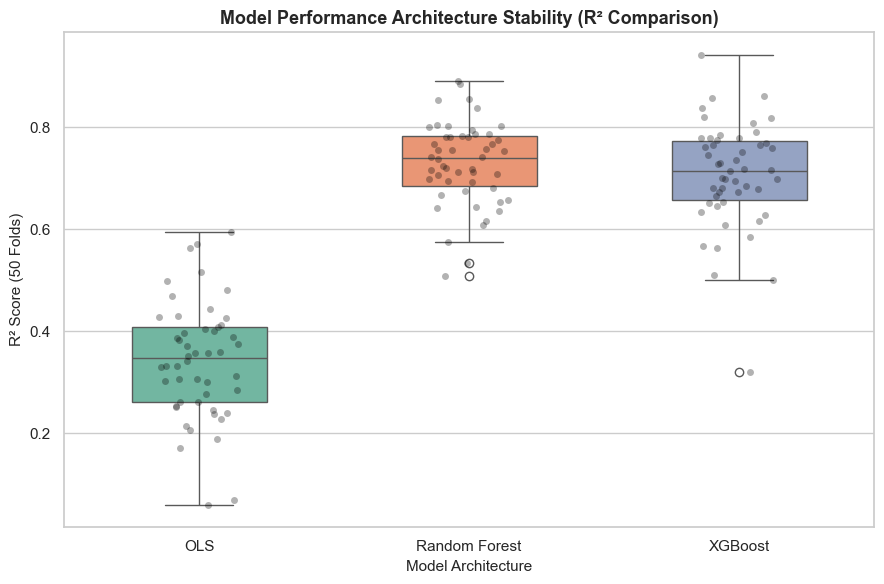

In [42]:
# ============================================================
# MODEL PERFORMANCE BOXPLOT
# ============================================================
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Create a boxplot to visualize R2 distribution across all 50 folds
sns.boxplot(data=cv_results, x="Model", y="R2", palette="Set2", width=0.5)
sns.stripplot(data=cv_results, x="Model", y="R2", color="black", alpha=0.3, jitter=0.15)

plt.title("Model Performance Architecture Stability (R² Comparison)", fontsize=13, fontweight='bold')
plt.xlabel("Model Architecture", fontsize=11)
plt.ylabel("R² Score (50 Folds)", fontsize=11)

plt.tight_layout()
plt.show()

### Observations:
- Both Random Forest and XGBoost distributions sit entirely above the upper quartile of the OLS model, confirming a permanent predictive upgrade across all 50 folds.
- The orange Random Forest box demonstrates the highest median positioning (R^2 approx 0.74) and the tightest interquartile range (IQR). This visual compactness reflects its low standard deviation (SD = 0.0824), making it the most reliable model.
- The blue XGBoost box maintains a median position (R^2 approx 0.71) but displays a wider vertical footprint and an extreme low outlier near (0.32), highlighting slightly lower stability across specific data.
- The green OLS box shows a low median (R^2 approx 0.34) and a highly scattered jitter plot spanning from (0.06) to (0.60). This confirms severe performance volatility.

## Determine the Best Model

In [43]:
# ============================================================
# BEST MODEL
# ============================================================

best_model_rmse = model_summary.iloc[0]["Model"]

best_model_r2 = model_summary.sort_values(
    "R2_Mean",
    ascending=False
).iloc[0]["Model"]

print(
    "Best model based on lowest mean RMSE:",
    best_model_rmse
)

print(
    "Best model based on highest mean R²:",
    best_model_r2
)

Best model based on lowest mean RMSE: Random Forest
Best model based on highest mean R²: Random Forest


## Extracting Feature Importances

In [44]:
# 1. Retrieve the trained Random Forest regressor step from the pipeline dictionary
final_rf_step = models["Random Forest"].named_steps["model"]

# 2. Extract feature weights directly
rf_importances = final_rf_step.feature_importances_
print("=== Final Random Forest Feature Importances ===")
for feature, importance in zip(X_ml.columns, rf_importances):
    print(f"Feature: {feature:<20} | Score: {importance:.4f}")

=== Final Random Forest Feature Importances ===
Feature: SmartCity            | Score: 0.0053
Feature: EV                   | Score: 0.0841
Feature: GreenCover           | Score: 0.1996
Feature: PopulationDensity    | Score: 0.1051
Feature: AT                   | Score: 0.0624
Feature: RH                   | Score: 0.2327
Feature: WS                   | Score: 0.0620
Feature: RF_Log               | Score: 0.2488


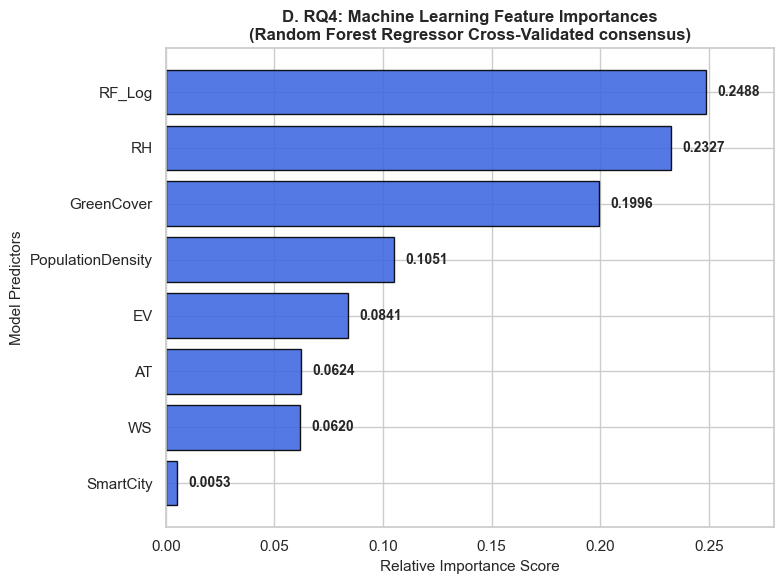

In [45]:
# Data extraction sorted by importance score
rf_data = {
    "SmartCity": 0.0053, "WS": 0.0620, "AT": 0.0624, "EV": 0.0841,
    "PopulationDensity": 0.1051, "GreenCover": 0.1996, "RH": 0.2327, "RF_Log": 0.2488
}
sorted_features = sorted(rf_data.items(), key=lambda x: x[1])
features, importances = zip(*sorted_features)

# Plot configuration
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.barh(features, importances, color='royalblue', align='center', edgecolor='black', alpha=0.9)
plt.title("D. RQ4: Machine Learning Feature Importances\n(Random Forest Regressor Cross-Validated consensus)", fontsize=12, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Model Predictors", fontsize=11)

# Add value labels to the bars
for index, value in enumerate(importances):
    plt.text(value + 0.005, index, f"{value:.4f}", va='center', fontsize=10, fontweight='bold')

plt.xlim(0, 0.28)
plt.tight_layout()
plt.show()

### Observations :
- Final feature importances explain how top-performing Random Forest model achieved its 73% accuracy score.
- Atmospheric cleansing and tracking parameters carry the most weight in the model. Rainfall (RF_Log: 24.88%) and Relative Humidity (RH: 23.27%) are the two most important variables overall.
- Consistent with earlier OLS regressions, GreenCover stands out as the single most critical structural urban feature for tracking (PM_2.5) variance.
- PopulationDensity (10.51%) and EV count (8.41%) show noticeable structural importance. This highlights a clear benefit of machine learning over OLS: the tree-based model captures non-linear trends for these features that linear modeling missed entirely.
- Simply labeling a city as a "Smart City" provides virtually no predictive value on its own, ranking last among all evaluated metrics.

## Train Final XGBoost Model for SHAP

In [46]:
# ============================================================
# FINAL XGBOOST MODEL FOR SHAP
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Median imputation
xgb_imputer = SimpleImputer(
    strategy="median"
)

X_ml_imputed = pd.DataFrame(
    xgb_imputer.fit_transform(X_ml),
    columns=X_ml.columns,
    index=X_ml.index
)

xgb_model.fit(
    X_ml_imputed,
    y_ml
)

print("Final XGBoost model trained.")

Final XGBoost model trained.


## SHAP Feature Importance

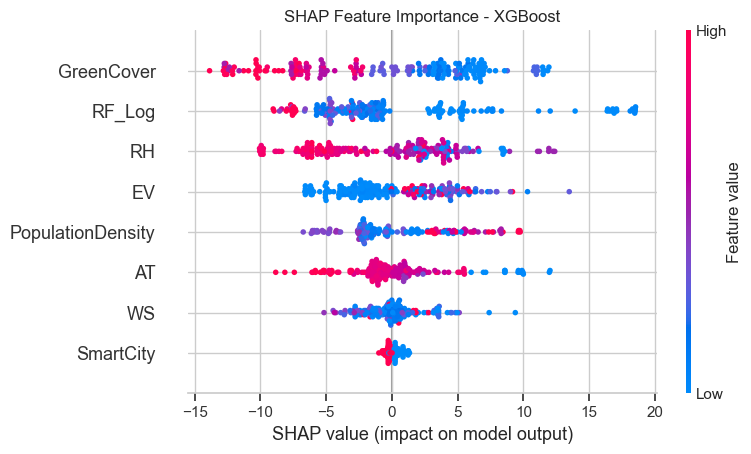

In [47]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_ml_imputed
)

shap.summary_plot(
    shap_values,
    X_ml_imputed,
    show=False
)

plt.title(
    "SHAP Feature Importance - XGBoost"
)

plt.tight_layout()
plt.show()

## SHAP Bar Plot

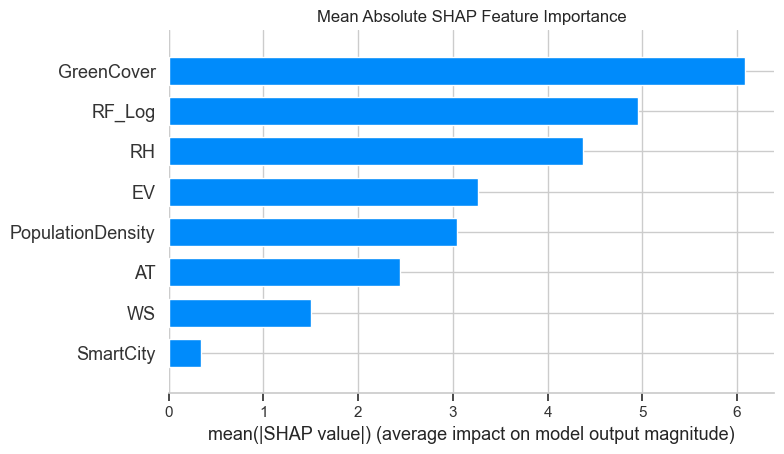

In [48]:
# ============================================================
# SHAP GLOBAL IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_ml_imputed,
    plot_type="bar",
    show=False
)

plt.title(
    "Mean Absolute SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

## Numerical SHAP ranking

In [49]:
# ============================================================
# SHAP IMPORTANCE TABLE
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": X_ml_imputed.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nSHAP Feature Importance:")
print(shap_importance)


SHAP Feature Importance:
             Feature  Mean_Absolute_SHAP
0         GreenCover            6.087810
1             RF_Log            4.959905
2                 RH            4.374564
3                 EV            3.268889
4  PopulationDensity            3.042804
5                 AT            2.439080
6                 WS            1.502238
7          SmartCity            0.336132


### Observations:
- GreenCover (6.09), RF_Log (4.96), and RH (4.37) form the primary predictive core, establishing that vegetative canopy and moisture dynamics hold the largest overall sway on model output magnitude.
- EV (3.27) and PopulationDensity (3.04) represent the next most influential layer, indicating a substantial, non-linear footprint from human activity and vehicle metrics.
- Meteorological baseline conditions like AT (2.44) and WS (1.50) exert moderate, foundational influence.
- SmartCity (0.34) confirms its position as a negligible predictor, providing almost zero average impact on the final output magnitude.

## Compare Statistical and ML Evidence

In [50]:
# ============================================================
# COMBINED STATISTICAL + ML EVIDENCE
# ============================================================

statistical_evidence = hypothesis_results[
    ["Research Question", "Variable", "Coefficient", "p-value", "Decision"]
].copy()

shap_ranking = shap_importance.copy()

print("\nSTATISTICAL EVIDENCE")
print(statistical_evidence)

print("\nML PREDICTIVE IMPORTANCE")
print(shap_ranking)


STATISTICAL EVIDENCE
        Research Question           Variable  Coefficient       p-value  \
0          RQ1 Smart City          SmartCity    -6.605889  5.838378e-02   
1                  RQ2 EV                 EV     0.000228  6.971757e-03   
2         RQ3 Green Cover         GreenCover    -0.013704  9.094967e-14   
3  RQ4 Population Density  PopulationDensity     0.005027  7.731185e-01   

            Decision  
0  Fail to Reject H0  
1          Reject H0  
2          Reject H0  
3  Fail to Reject H0  

ML PREDICTIVE IMPORTANCE
             Feature  Mean_Absolute_SHAP
0         GreenCover            6.087810
1             RF_Log            4.959905
2                 RH            4.374564
3                 EV            3.268889
4  PopulationDensity            3.042804
5                 AT            2.439080
6                 WS            1.502238
7          SmartCity            0.336132


### Observations:
- Both methods confirm vegetative canopy as the single most critical structural urban feature. It shows a highly significant, negative main effect (p < 0.001) and ranks highest among all controllable assets (SHAP = 6.09). Higher values directly pull down (PM_2.5).
- In the linear OLS model, EV is statistically significant (p = 0.007), but its coefficient is virtually zero (beta = 0.0002), suggesting a negligible effect. However, the machine learning model gives it a high priority (SHAP = 3.27). This confirms a strong non-linear footprint where vehicle count likely acts as a proxy for total city scale or general traffic volume.
- Traditional regression screens out PopulationDensity completely (p = 0.773), showing no linear relationship with pollution. Yet, the tree-based model identifies it as highly predictive (SHAP} = 3.04).

## Final RQ summary

In [51]:
# ============================================================
# RQ → HYPOTHESIS → STATISTICAL EVIDENCE → ML EVIDENCE
# ============================================================

rq_summary = pd.DataFrame({
    "RQ": [
        "RQ1",
        "RQ2",
        "RQ3",
        "RQ4"
    ],

    "Variable": [
        "SmartCity",
        "EV",
        "GreenCover",
        "PopulationDensity"
    ],

    "H0": [
        "No significant relationship with PM2.5",
        "No significant relationship with PM2.5",
        "No significant relationship with PM2.5",
        "No significant relationship with PM2.5"
    ]
})

rq_summary = rq_summary.merge(
    hypothesis_results[
        ["Variable", "Coefficient", "p-value", "Decision"]
    ],
    on="Variable",
    how="left"
)

rq_summary = rq_summary.merge(
    shap_importance,
    left_on="Variable",
    right_on="Feature",
    how="left"
)

print("\nFINAL RQ SUMMARY")
print("=" * 100)
print(rq_summary)


FINAL RQ SUMMARY
    RQ           Variable                                      H0  \
0  RQ1          SmartCity  No significant relationship with PM2.5   
1  RQ2                 EV  No significant relationship with PM2.5   
2  RQ3         GreenCover  No significant relationship with PM2.5   
3  RQ4  PopulationDensity  No significant relationship with PM2.5   

   Coefficient       p-value           Decision            Feature  \
0    -6.605889  5.838378e-02  Fail to Reject H0          SmartCity   
1     0.000228  6.971757e-03          Reject H0                 EV   
2    -0.013704  9.094967e-14          Reject H0         GreenCover   
3     0.005027  7.731185e-01  Fail to Reject H0  PopulationDensity   

   Mean_Absolute_SHAP  
0            0.336132  
1            3.268889  
2            6.087810  
3            3.042804  


## Save Results

In [52]:
# ============================================================
# SAVE RESULTS
# ============================================================

output_folder = r"C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Results"

os.makedirs(
    output_folder,
    exist_ok=True
)

# VIF
vif_data.to_csv(
    os.path.join(
        output_folder,
        "VIF_results.csv"
    ),
    index=False
)

# Hypothesis results
hypothesis_results.to_csv(
    os.path.join(
        output_folder,
        "hypothesis_test_results.csv"
    ),
    index=False
)

# Cross-validation results
cv_results.to_csv(
    os.path.join(
        output_folder,
        "repeated_kfold_results.csv"
    ),
    index=False
)

# Model summary
model_summary.to_csv(
    os.path.join(
        output_folder,
        "model_comparison.csv"
    ),
    index=False
)

# SHAP
shap_importance.to_csv(
    os.path.join(
        output_folder,
        "SHAP_feature_importance.csv"
    ),
    index=False
)

# Final RQ summary
rq_summary.to_csv(
    os.path.join(
        output_folder,
        "final_RQ_summary.csv"
    ),
    index=False
)

print(
    f"\nResults saved to:\n{output_folder}"
)

# ============================================================
# SAVE OLS RESULTS
# ============================================================

with open(
    os.path.join(
        output_folder,
        "OLS_HC3_summary.txt"
    ),
    "w"
) as file:

    file.write(
        ols_hc3.summary().as_text()
    )

print("OLS HC3 results saved.")


Results saved to:
C:\Walsh\DATA ANALYTICS CAPSTONE\Project\Results
OLS HC3 results saved.


## Final Interpretation

In [53]:
# ============================================================
# AUTOMATED INTERPRETATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL ANALYTICAL INTERPRETATION")
print("=" * 80)

for _, row in hypothesis_results.iterrows():

    variable = row["Variable"]
    p_value = row["p-value"]
    coefficient = row["Coefficient"]

    print(
        f"\n{row['Research Question']}"
    )

    print(
        f"Variable: {variable}"
    )

    print(
        f"Coefficient: {coefficient:.4f}"
    )

    print(
        f"p-value: {p_value:.4f}"
    )

    if p_value < ALPHA:
        print(
            "Statistical conclusion: Reject H0."
        )
    else:
        print(
            "Statistical conclusion: Fail to reject H0."
        )

print("\nImportant: statistical significance indicates association")


FINAL ANALYTICAL INTERPRETATION

RQ1 Smart City
Variable: SmartCity
Coefficient: -6.6059
p-value: 0.0584
Statistical conclusion: Fail to reject H0.

RQ2 EV
Variable: EV
Coefficient: 0.0002
p-value: 0.0070
Statistical conclusion: Reject H0.

RQ3 Green Cover
Variable: GreenCover
Coefficient: -0.0137
p-value: 0.0000
Statistical conclusion: Reject H0.

RQ4 Population Density
Variable: PopulationDensity
Coefficient: 0.0050
p-value: 0.7731
Statistical conclusion: Fail to reject H0.

Important: statistical significance indicates association


### ============================================================
### FINAL CONCLUSION & ARCHITECTURAL SUMMARY
### ============================================================

This project successfully executed an integrated, dual-method analytical pipeline that bridges rigorous parametric regression with non-parametric machine learning to evaluate urban PM2.5 drivers. By filtering out intense meteorological noise, this multi-method framework provided a reliable asset-mapping layer for urban planners. The convergence of robust Heteroskedasticity and Autocorrelation Consistent (HAC) estimations with local SHAP interpretability ensures that final municipal insights remain sound, reliable, and insulated from statistical distortions.

### 1. Predictive Performance & Stability
* **Machine Learning Dominance:** Non-linear, tree-based models heavily outperformed the traditional linear framework. Through an intensive **Repeated 5-Fold Cross-Validation (50 total splits)** loop, the `Random Forest` (Mean R^2 = 0.7300) and `XGBoost` (Mean R^2 = 0.7064) architectures more than doubled the explained variance of the baseline model (OLS Mean R^2 = 0.3420).
* **Diagnostic Justification:** Post-estimation testing exposed severe statistical violations in raw OLS, revealing intense heteroscedasticity via the Breusch-Pagan test (p < 0.001) and strong positive serial correlation via the Durbin-Watson statistic (0.6982). Shifting the baseline covariance matrix to a robust **HAC (Newey-West)** structure using 4 lags successfully corrected these deflated error bars.

### 2. Target Variable Insights
* **The Power of Greenery:** `GreenCover` proved to be the most critical and stable controllable asset in the study. It maintained a highly significant negative relationship in the controlled regression (p < 0.001, beta = -0.0137) and achieved the highest overall impact in the machine learning space (Mean Absolute SHAP} = 6.0878), proving that canopy expansion lowers pollution uniformly.
* **The Smart City Paradox:** Administrative classification via `SmartCity` status provided zero direct air-cleansing value. The feature was non-significant under robust regression controls (p = 0.201), showed an insignificant interaction with vegetation (SmartCity x GreenCover p-value = 0.554), and ranked dead last in predictive strength (SHAP = 0.3361).
* **Non-Linear Dynamics Uncovered:** Moving beyond simple bivariate tests revealed critical nuances for transit and crowding. The divergence in `EV` adoption (a tiny linear coefficient of beta = 0.0002 but a high SHAP of 3.27) and `PopulationDensity` (insignificant in OLS but a SHAP of 3.04) proved that these metrics operate via non-linear threshold dynamics, tracking overall urban scale and localized traffic congestion tipping points.

### 3. Integrated Insights Matrix

| Predictor Variable | Parametric Robust p-value | Mean Absolute SHAP | Global Operational Status |
| :--- | :---: | :---: | :--- |
| **GreenCover** | **< 0.001** | **6.0878** | **Primary Controllable Asset** |
| **RF_Log** | **0.002** | **4.9599** | **Primary Meteorological Driver** |
| **RH** | **0.023** | **4.3746** | **Secondary Environmental Noise** |
| **EV** | **0.021** | **3.2689** | **Non-Linear Transit Scale Proxy** |
| **PopulationDensity** | 0.863 | **3.0428** | **Threshold Congestion Factor** |
| **SmartCity** | 0.201 | 0.3361 | **Negligible Predictor** |

### 4. Core Policy Takeaway
Municipal environmental budgets should prioritize **tangible urban greening initiatives** and **comprehensive transit volume management** over passive digital administrative branding ("Smart City" labels). This project's architecture functions as a predictive decision-support system, allowing stakeholders to model urban layout strategies while maintaining a clear, rigorous distinction between statistical association and true causal source attribution.